# 🌌 Clustering II — DBSCAN, HDBSCAN and Gaussian Mixtures

> **What you'll learn:** how to find clusters of **any shape** and label **noise** with density-based clustering (DBSCAN, OPTICS, HDBSCAN), and how to do **soft, probabilistic** clustering with Gaussian mixture models trained by the EM algorithm. You'll pick `eps` from a k-distance plot, handle clusters of different densities, choose the number of mixture components with BIC/AIC, turn a mixture into an anomaly score, compare every clustering algorithm from notebooks 12–13 on the same real data, and find ride-hailing pickup hotspots in New York City.

| | |
|---|---|
| **Difficulty** | 🟡 Intermediate → 🔴 Interview depth |
| **Time** | ~4 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [Clustering I — K-Means and Hierarchical](12_Clustering_KMeans_and_Hierarchical.ipynb) (K-Means, linkages, silhouette, ARI) · [Statistics and Probability](../01_Core_Scientific_Computing/05_Statistics_and_Probability.ipynb) (normal distribution, likelihood, Bayes' rule) |
| **Tested with** | Python 3.12 · scikit-learn 1.9 · scipy 1.18 · numpy 2.5 · pandas 3.0 · seaborn 0.13 · matplotlib 3.11 |
| **Interview relevance** | ⭐⭐⭐ High — "DBSCAN vs K-Means", "how do you choose eps?", core/border/noise points, "explain the EM algorithm", "GMM vs K-Means", BIC vs AIC, covariance types, geospatial hotspot and anomaly-detection case studies |

## 🤔 What Is Density-Based and Probabilistic Clustering?

**Density-based clustering.** Look at a satellite photo of a country at night. Cities are bright, **dense** patches of light, and they can have any shape: a long strip along a coast, a ring around a bay. The dark countryside has a few scattered lights that don't belong to any city. **DBSCAN** and its relatives do exactly this: a cluster is a **region where points are packed closely together**, and isolated points are labelled **noise**.

```
  ● ● ●●●                  ● core point   : has ≥ min_samples points within distance eps
 ●●●●●●●●  ○               ○ border point : not core itself, but within eps of a core point
  ●●●●●●●●○                × noise        : neither — belongs to no cluster (label -1)
       ●●●●●●
             ●●●     ×     A cluster = core points that are chained together through eps-neighbourhoods,
  ×                           plus the border points they reach. Any shape is allowed.
```

**Probabilistic (model-based) clustering.** Imagine two friend groups mingling at a party. For someone standing between them you would rather say *"70% likely group A, 30% group B"* than force a yes/no answer. A **Gaussian mixture model (GMM)** assumes the data came from several bell-shaped (Gaussian) blobs, each with its own centre, shape and size. It gives every point a **probability** of belonging to each blob. The **EM algorithm** learns those blobs.

| | K-Means (notebook 12) | DBSCAN / HDBSCAN | Gaussian mixture |
|---|---|---|---|
| Cluster = | points nearest one centroid | dense connected region | one Gaussian component |
| Shape | round, similar size | **any shape** | **ellipses** of any size/orientation |
| Number of clusters | you choose k | found from the data | you choose k (BIC helps) |
| Noise | none: every point is assigned | **explicit noise label −1** | none, but low density = unusual |
| Assignment | hard | hard | **soft probabilities** |

## 🎯 Why It Matters

- **Geospatial analytics.** Ride-hailing pickup hotspots, delivery zones, crime and accident hotspots and GPS stop detection are classic DBSCAN/HDBSCAN jobs: the clusters follow streets and neighbourhoods, and scattered points should stay unassigned. You'll build a hotspot detector on real New York pickups.
- **Noise and anomalies.** Density methods label outliers for free, and a GMM's log-density is a ready-made **anomaly score** (fraud, sensor faults, unusual transactions).
- **Soft segmentation.** GMM probabilities flag customers or documents that sit between segments, which is often the most interesting group.
- **Density estimation and generation.** GMMs model a probability distribution you can sample from; they were used in classic speech recognition and in video background subtraction (OpenCV's MOG2), and they are the textbook example of the EM algorithm, which also appears in hidden Markov models, missing-data problems and topic models.
- **Embeddings.** HDBSCAN on text or user embeddings (usually after UMAP) is a popular way to discover topics without choosing k (e.g. the BERTopic library).
- **In interviews:** *"When would you use DBSCAN over K-Means?"*, *"How do you choose eps and min_samples?"*, *"What are core, border and noise points?"*, *"Walk me through the EM algorithm"*, *"How is a GMM different from K-Means?"*, *"BIC vs AIC?"*, *"Why does DBSCAN struggle with varying density?"*, and design questions like *"find hotspots in location data"*. This notebook practises all of them.

## 🃏 Algorithm Card

| | **DBSCAN** | **HDBSCAN** (and OPTICS) | **Gaussian Mixture Model** |
|---|---|---|---|
| **Learning type** | Unsupervised | Unsupervised | Unsupervised (generative, probabilistic) |
| **Tasks** | Clustering with noise, arbitrary shapes, outlier flagging | Clustering with varying densities, hotspots, topic discovery on embeddings | Soft clustering, density estimation, anomaly scoring, sampling new data |
| **Model / objective** | No global loss: clusters are maximal sets of **density-connected** points (≥ `min_samples` within `eps`) | Builds a cluster hierarchy over **all** density levels (mutual-reachability MST) and keeps the most **stable** clusters (excess of mass); OPTICS orders points by reachability distance | Maximize the log-likelihood $\sum_i \log \sum_k \pi_k \mathcal{N}(x_i \mid \mu_k, \Sigma_k)$ with the **EM algorithm** |
| **Key hyperparameters (typical ranges)** | `eps` (from a k-distance plot), `min_samples` (≥ d+1; ~2·d; 5–50), `metric` | HDBSCAN: `min_cluster_size` (5–500), `min_samples` (default = `min_cluster_size`), `cluster_selection_method` (`"eom"`/`"leaf"`); OPTICS: `min_samples`, `xi` (0.01–0.1) | `n_components` (by BIC), `covariance_type` (`full`/`tied`/`diag`/`spherical`), `n_init` (1–10), `reg_covar` (1e-6) |
| **Needs feature scaling?** | **Yes** — one `eps` for every direction | **Yes** | **Yes** for spherical/diag; full covariance adapts to scale but scaling still helps numerically |
| **Handles missing values / categoricals?** | No / via `metric="precomputed"` (e.g. Gower distances) | No / via a precomputed distance matrix | No / No (numeric features only) |
| **Training & prediction complexity** | ~$O(n \log n)$ with a spatial index in low dimensions, up to $O(n^2)$; **no `predict`** | HDBSCAN ~$O(n \log n)$ low-d, up to $O(n^2)$; OPTICS slower in practice; **no `predict`** | $O(n\,k\,d^2)$ per EM iteration (full covariance) + $O(k\,d^3)$; `predict`/`predict_proba` $O(k\,d^2)$ per point |
| **Interpretability** | Medium — clusters are point sets; noise is explicit | Medium — hierarchy, membership strengths (`probabilities_`) | High — weights, means, covariances, per-point probabilities |
| **Strengths** | Any shape, finds k itself, labels noise, just 2 parameters | Handles **varying density**, almost parameter-free, robust hotspots | Soft assignments, elliptical clusters of different sizes, a true density model, BIC for model selection |
| **Weaknesses** | One global density (`eps`) fails when densities vary; sensitive to `eps`; weak in high dimensions | Can leave many points as noise; no `predict`; OPTICS is slow in scikit-learn | Must pick k; assumes Gaussian blobs; local optima; covariance can become singular |
| **Use it when** | Low-dimensional data (e.g. coordinates) with dense groups of similar density and noise | Densities vary (city centre vs suburbs), you don't know k, noise is expected | Clusters overlap, you need probabilities or a density/anomaly score, groups are roughly elliptical |
| **Avoid it when** | Densities vary a lot or dimensionality is high (> ~15) without reduction | You need every point assigned or fast assignment of new points | Clusters are non-convex (moons, rings) or data is very high-dimensional with few rows |
| **Best libraries** | scikit-learn `DBSCAN` (`metric="haversine"` for lat/lon); cuML on GPU | scikit-learn `HDBSCAN`, `OPTICS`; the `hdbscan` package (adds `approximate_predict`, GLOSH outlier scores) | scikit-learn `GaussianMixture`, `BayesianGaussianMixture` |

## ✅ By the End You Can

- [ ] Define core, border and noise points and run DBSCAN by hand
- [ ] Choose `eps` and `min_samples` from a k-distance plot and explain why one `eps` fails when densities vary
- [ ] Use OPTICS and HDBSCAN, read a reachability plot, and handle noise points in a real pipeline
- [ ] Explain Gaussian mixtures, soft assignments, covariance types and the E and M steps of EM (in words and math)
- [ ] Choose the number of components with BIC/AIC and turn a GMM into an anomaly score
- [ ] Implement DBSCAN and EM from scratch and match scikit-learn
- [ ] Compare all clustering algorithms from notebooks 12–13 and pick one for a real problem

## 📋 Table of Contents

1. [Density-Based Clustering: Core, Border, and Noise Points](#1.-Density-Based-Clustering:-Core,-Border,-and-Noise-Points-🟢)
2. [Choosing eps and min_samples: the k-Distance Plot](#2.-Choosing-eps-and-min_samples:-the-k-Distance-Plot-🟡)
3. [Arbitrary Shapes: DBSCAN vs K-Means](#3.-Arbitrary-Shapes:-DBSCAN-vs-K-Means-🟢)
4. [Varying Density: OPTICS and HDBSCAN](#4.-Varying-Density:-OPTICS-and-HDBSCAN-🟡)
5. [Handling Noise](#5.-Handling-Noise-🟡)
6. [Gaussian Mixture Models: Soft Clustering](#6.-Gaussian-Mixture-Models:-Soft-Clustering-🟢)
7. [The EM Algorithm](#7.-The-EM-Algorithm-🟡)
8. [Covariance Types and Choosing Components with BIC/AIC](#8.-Covariance-Types-and-Choosing-Components-with-BIC/AIC-🟡)
9. [GMM as a Density Model: Anomaly Scores](#9.-GMM-as-a-Density-Model:-Anomaly-Scores-🟡)
10. [Comparing Every Clustering Algorithm](#10.-Comparing-Every-Clustering-Algorithm-🔴)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-NYC-Pickup-Hotspots) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a library is missing, uncomment the `%pip` line, run it once, then restart the kernel.

The `check()` helper gives you instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

**Datasets (all real):**
- **Uber pickups in New York City, April 2014** (26 MB, downloaded once to `_outputs/`): 564,516 pickups with date/time, latitude and longitude. The NYC Taxi & Limousine Commission released these trip records to FiveThirtyEight under a New York Freedom of Information Law request, and FiveThirtyEight published them in the [uber-tlc-foil-response](https://github.com/fivethirtyeight/uber-tlc-foil-response) repository. The repository has no separate licence file; it is widely used for teaching, but check the terms before any commercial use.
- **Palmer penguins** (via seaborn, cached in `_outputs/`, CC0): 333 penguins with 4 measurements and the true species, which we hide while clustering.
- **Wine** and **handwritten digits** (built into scikit-learn) for the algorithm comparison.

**Coordinates → kilometres.** Distances in degrees are misleading: in New York one degree of longitude is about 84 km but one degree of latitude is about 111 km (Pitfall 1). We use a simple local projection, $x = (\text{lon} - \text{lon}_0) \cdot 111.32 \cdot \cos(\text{lat}_0)$, $y = (\text{lat} - \text{lat}_0) \cdot 110.57$. Within ~50 km of the reference point its error is well under 1%, so `eps` can be written in **kilometres**.

In [1]:
# %pip install -q "scikit-learn>=1.6" "scipy>=1.13" "pandas>=2.2" "seaborn>=0.13" matplotlib

import gc
import sys
import time
import urllib.request
import warnings
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
import sklearn
from matplotlib.patches import Ellipse
from scipy.optimize import linear_sum_assignment
from scipy.stats import norm
from sklearn.cluster import (DBSCAN, HDBSCAN, OPTICS, AgglomerativeClustering, BisectingKMeans, KMeans,
                             MiniBatchKMeans, cluster_optics_dbscan)
from sklearn.datasets import load_digits, load_wine, make_circles, make_moons
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

print(f"Python {sys.version.split()[0]} | scikit-learn {sklearn.__version__} | scipy {scipy.__version__} | "
      f"numpy {np.__version__} | pandas {pd.__version__} | seaborn {sns.__version__} | matplotlib {matplotlib.__version__}")

SEED = 42
rng = np.random.default_rng(SEED)
pd.set_option("display.precision", 3)
pd.set_option("display.width", 140)
OUTPUT_DIR = Path("_outputs")              # files we write go here (ignored by git)
OUTPUT_DIR.mkdir(exist_ok=True)

UBER_URL = ("https://raw.githubusercontent.com/fivethirtyeight/uber-tlc-foil-response/master/"
            "uber-trip-data/uber-raw-data-apr14.csv")
UBER_PATH = OUTPUT_DIR / "uber-raw-data-apr14.csv"
if not UBER_PATH.exists():
    print("downloading Uber April 2014 pickups (26 MB) ...")
    urllib.request.urlretrieve(UBER_URL, UBER_PATH)

LAT0, LON0 = 40.73, -73.99                 # reference point for the km projection (lower Manhattan)


def to_km(lat, lon):
    """Local equirectangular projection: degrees → kilometres east (x) and north (y) of (LAT0, LON0)."""
    lat, lon = np.asarray(lat, dtype=float), np.asarray(lon, dtype=float)
    return np.column_stack([(lon - LON0) * 111.32 * np.cos(np.radians(LAT0)), (lat - LAT0) * 110.57])


def to_latlon(xy):
    xy = np.atleast_2d(xy)
    return np.column_stack([LAT0 + xy[:, 1] / 110.57, LON0 + xy[:, 0] / (111.32 * np.cos(np.radians(LAT0)))])


LANDMARKS = {                              # (latitude, longitude) of well-known places, for labelling results
    "Times Square": (40.7580, -73.9855), "Penn Station": (40.7506, -73.9935), "Grand Central": (40.7527, -73.9772),
    "Wall Street": (40.7069, -74.0113), "Union Square": (40.7359, -73.9911), "West Village": (40.7334, -74.0027),
    "Upper East Side": (40.7795, -73.9555), "Williamsburg": (40.7171, -73.9566), "Downtown Brooklyn": (40.6931, -73.9900),
    "JFK Airport": (40.6413, -73.7781), "LaGuardia Airport": (40.7769, -73.8740), "Newark Airport": (40.6895, -74.1745),
}
LANDMARK_XY = {name: to_km(*latlon)[0] for name, latlon in LANDMARKS.items()}


def check(name, got, expected, hint="", rtol=1e-4, atol=1e-6):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    if isinstance(expected, dict):
        ok = isinstance(got, dict) and set(got) == set(expected) and all(
            np.allclose(got[k], expected[k], rtol=rtol, atol=atol) for k in expected)
    elif isinstance(expected, (bool, np.bool_, str)):
        ok = got == expected
    else:
        try:
            g, e = np.asarray(got, dtype=float), np.asarray(expected, dtype=float)
        except (TypeError, ValueError):
            raise AssertionError(f"❌ {name}: expected a number/array, got {type(got).__name__}. {hint}")
        if g.shape != e.shape:
            raise AssertionError(f"❌ {name}: shape {g.shape}, expected {e.shape}. {hint}")
        ok = np.allclose(g, e, rtol=rtol, atol=atol)
    assert ok, f"❌ {name}: not quite. {hint}"
    print(f"✅ {name}: correct!")

Python 3.12.11 | scikit-learn 1.9.1 | scipy 1.18.1 | numpy 2.5.3 | pandas 3.0.5 | seaborn 0.13.2 | matplotlib 3.11.2


## 1. Density-Based Clustering: Core, Border, and Noise Points 🟢

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise; Ester et al., 1996) needs two parameters:

- **`eps`** ($\varepsilon$): the neighbourhood radius.
- **`min_samples`**: how many points (**including the point itself**, in scikit-learn) must lie within `eps` for a point to count as dense.

Definitions, with $N_\varepsilon(p) = \{q : d(p, q) \le \varepsilon\}$:

| Term | Rule |
|---|---|
| **Core point** | $|N_\varepsilon(p)| \ge$ `min_samples` |
| **Directly reachable** | $q \in N_\varepsilon(p)$ and $p$ is a core point |
| **Density-connected** | $p$ and $q$ can both be reached through a chain of core points |
| **Border point** | not core, but inside the neighbourhood of at least one core point |
| **Noise** | neither core nor border → label `-1` |

**The algorithm:** visit points in order. When you find an unlabelled **core** point, start a new cluster and grow it: add every point in its neighbourhood, and keep expanding from the ones that are also core points (a breadth- or depth-first search). When the search runs out, move on to the next unlabelled core point. Whatever is never reached is noise.

Let's look at real data: Uber pickups around **LaGuardia Airport** during April 2014.

In [2]:
uber = pd.read_csv(UBER_PATH)
uber["Date/Time"] = pd.to_datetime(uber["Date/Time"], format="%m/%d/%Y %H:%M:%S")
uber_xy_all = to_km(uber["Lat"], uber["Lon"])
print(f"{len(uber):,} pickups from {uber['Date/Time'].min():%Y-%m-%d} to {uber['Date/Time'].max():%Y-%m-%d}")
print(uber.head(3))
print(f"x (km east) range: {uber_xy_all[:, 0].min():.1f} … {uber_xy_all[:, 0].max():.1f} | "
      f"median distance from lower Manhattan: {np.median(np.linalg.norm(uber_xy_all, axis=1)):.1f} km")

564,516 pickups from 2014-04-01 to 2014-04-30
            Date/Time     Lat     Lon    Base
0 2014-04-01 00:11:00  40.769 -73.955  B02512
1 2014-04-01 00:17:00  40.727 -74.034  B02512
2 2014-04-01 00:21:00  40.732 -73.987  B02512
x (km east) range: -66.1 … 162.3 | median distance from lower Manhattan: 3.0 km


10,689 April pickups in the 3×3 km LaGuardia window; sampled 600
eps=0.12 km, min_samples=8: 4 clusters | core 564 | border 8 | noise 28


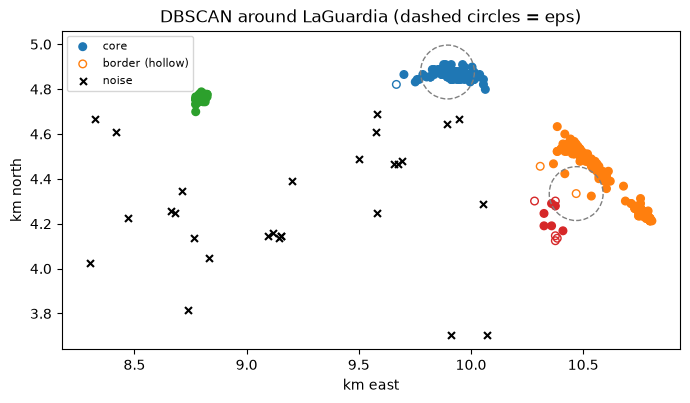

In [3]:
lga = LANDMARK_XY["LaGuardia Airport"]
in_window = np.flatnonzero(np.all(np.abs(uber_xy_all - lga) <= 1.5, axis=1))      # a 3 km × 3 km square
window_idx = rng.choice(in_window, size=min(600, len(in_window)), replace=False)
X_lga = uber_xy_all[window_idx]
EPS_DEMO, MS_DEMO = 0.12, 8
db_demo = DBSCAN(eps=EPS_DEMO, min_samples=MS_DEMO).fit(X_lga)
core_mask = np.zeros(len(X_lga), dtype=bool)
core_mask[db_demo.core_sample_indices_] = True
noise_mask = db_demo.labels_ == -1
border_mask = ~core_mask & ~noise_mask
print(f"{len(in_window):,} April pickups in the 3×3 km LaGuardia window; sampled {len(X_lga)}")
print(f"eps={EPS_DEMO} km, min_samples={MS_DEMO}: {db_demo.labels_.max() + 1} clusters | core {core_mask.sum()} | "
      f"border {border_mask.sum()} | noise {noise_mask.sum()}")

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(*X_lga[core_mask].T, color=plt.cm.tab10(db_demo.labels_[core_mask] % 10), s=30, label="core")
ax.scatter(*X_lga[border_mask].T, facecolors="none", edgecolors=plt.cm.tab10(db_demo.labels_[border_mask] % 10), s=30,
           marker="o", label="border (hollow)")
ax.scatter(*X_lga[noise_mask].T, c="black", marker="x", s=25, label="noise")
for idx in [np.flatnonzero(core_mask)[0], np.flatnonzero(border_mask)[0] if border_mask.any() else 0]:
    ax.add_patch(plt.Circle(X_lga[idx], EPS_DEMO, fill=False, ls="--", color="grey"))
ax.set(title="DBSCAN around LaGuardia (dashed circles = eps)", xlabel="km east", ylabel="km north", aspect="equal")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

Dense groups of pickups (the terminal kerbs) become clusters; scattered pickups on nearby streets become noise. Border points sit at the edge of dense areas. Nobody told DBSCAN how many clusters to find.

### ✍️ Your Turn

Classify each 1-D point as `"core"`, `"border"` or `"noise"` for `eps=0.5`, `min_samples=3` (a point counts itself). Write the answer as one comma-separated string, e.g. `"core,noise,..."`.

In [4]:
points_1d = np.array([[0.0], [0.5], [1.0], [1.4], [5.0]])
point_types = None  # TODO: e.g. "border,core,..." (you can reason by hand or use DBSCAN's core_sample_indices_ and labels_)
check("point_types", point_types, "border,core,core,border,noise",
      hint="Count neighbours within 0.5 including the point itself; a non-core point near a core point is a border point.")

⏳ point_types: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
points_1d = np.array([[0.0], [0.5], [1.0], [1.4], [5.0]])
model = DBSCAN(eps=0.5, min_samples=3).fit(points_1d)
is_core = np.isin(np.arange(len(points_1d)), model.core_sample_indices_)
point_types = ",".join("core" if c else ("noise" if lab == -1 else "border") for c, lab in zip(is_core, model.labels_))
check("point_types", point_types, "border,core,core,border,noise")
```

Point 0.5 has {0, 0.5, 1.0} within 0.5 → 3 → core. Point 1.0 has {0.5, 1.0, 1.4} → core. Points 0 and 1.4 have only 2 neighbours but touch a core point → border. Point 5 is alone → noise.
</details>

> 💡 **Interview angle:** "Explain core, border and noise points." — a core point has at least `min_samples` points (itself included) within `eps`; a border point isn't core but lies within `eps` of a core point; everything else is noise. Clusters are chains of core points plus their borders, so they can take any shape and k is never specified.

## 2. Choosing eps and min_samples: the k-Distance Plot 🟡

**`min_samples`** first, because it is less sensitive:
- at least $d + 1$ (for $d$ features); a common default is $2 \cdot d$;
- larger values give smoother, more conservative clusters and more noise. Use them for noisy or large data.

**`eps`** from the **k-distance plot** (with $k$ = `min_samples`):
1. For every point, compute the distance to its $k$-th nearest neighbour, **counting the point itself** as the first (exactly how `min_samples` works). This is the smallest `eps` that would make that point a core point.
2. Sort these distances and plot them.
3. Points inside clusters have small k-distances; noise points have large ones. The **knee** where the curve shoots up is a natural `eps`. We locate it as the point farthest below the straight line joining both ends of the curve.

The knee is a starting point, not a law: it separates "points in any cluster" from "noise". Your *question* may need a stricter density. We work with a random sample of **20,000 April pickups** to keep things fast.

k-distance (k=20) quantiles in km: median 0.091, 90% 0.356, 99% 3.711 | knee → eps ≈ 1.837 km


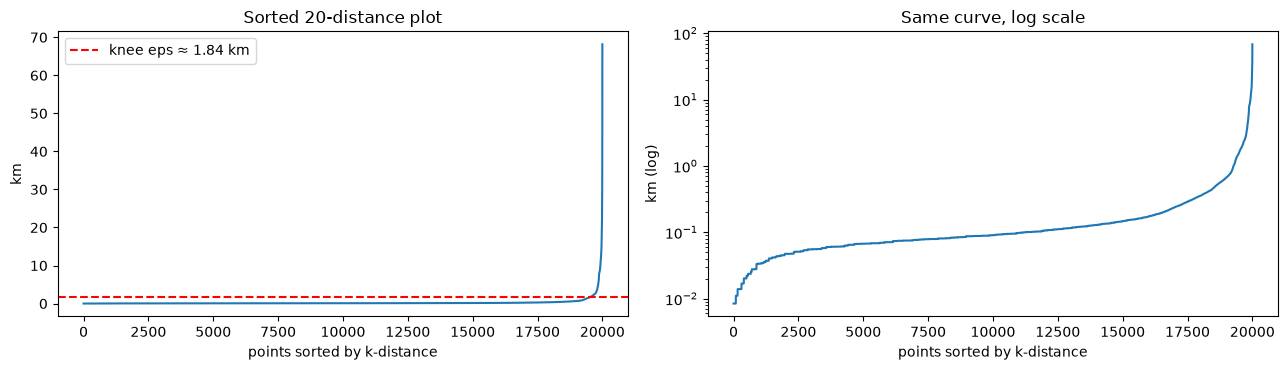

In [5]:
sample_idx = rng.choice(len(uber), size=20_000, replace=False)
X_uber = uber_xy_all[sample_idx]


def k_distances(X, k):
    """Sorted distance from each point to its k-th nearest neighbour, the point itself counting as the first."""
    dist, _ = NearestNeighbors(n_neighbors=k).fit(X).kneighbors(X)
    return np.sort(dist[:, -1])


def knee_value(sorted_values):
    """Knee of an increasing convex curve: the point farthest below the chord joining its ends (normalized axes)."""
    x = np.linspace(0, 1, len(sorted_values))
    y = (sorted_values - sorted_values[0]) / (sorted_values[-1] - sorted_values[0])
    return float(sorted_values[np.argmax(x - y)])


MIN_SAMPLES = 20
kdist = k_distances(X_uber, MIN_SAMPLES)
eps_knee = knee_value(kdist)
print(f"k-distance (k={MIN_SAMPLES}) quantiles in km: median {np.median(kdist):.3f}, 90% {np.quantile(kdist, 0.9):.3f}, "
      f"99% {np.quantile(kdist, 0.99):.3f} | knee → eps ≈ {eps_knee:.3f} km")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].plot(kdist)
axes[0].axhline(eps_knee, color="red", ls="--", label=f"knee eps ≈ {eps_knee:.2f} km")
axes[0].set(title=f"Sorted {MIN_SAMPLES}-distance plot", xlabel="points sorted by k-distance", ylabel="km")
axes[0].legend()
axes[1].plot(kdist)
axes[1].set(title="Same curve, log scale", xlabel="points sorted by k-distance", ylabel="km (log)", yscale="log")
plt.tight_layout()
plt.show()

 eps km  min_samples  clusters  noise %  largest cluster %  seconds
   0.10           10        71    18.08              69.45     0.03
   0.10           20        62    31.15              50.44     0.03
   0.10           50        31    74.48               7.30     0.03
   0.25           10        28     7.41              78.68     0.06
   0.25           20        24    11.29              78.01     0.06
   0.25           50        11    17.38              76.68     0.06
   0.50           10        12     3.66              79.57     0.12
   0.50           20        12     5.44              79.26     0.12
   0.50           50         7     9.72              78.38     0.11
   1.84           10         4     1.09              96.10     0.47
   1.84           20         4     1.57              95.62     0.39
   1.84           50         3     2.60              94.67     0.38


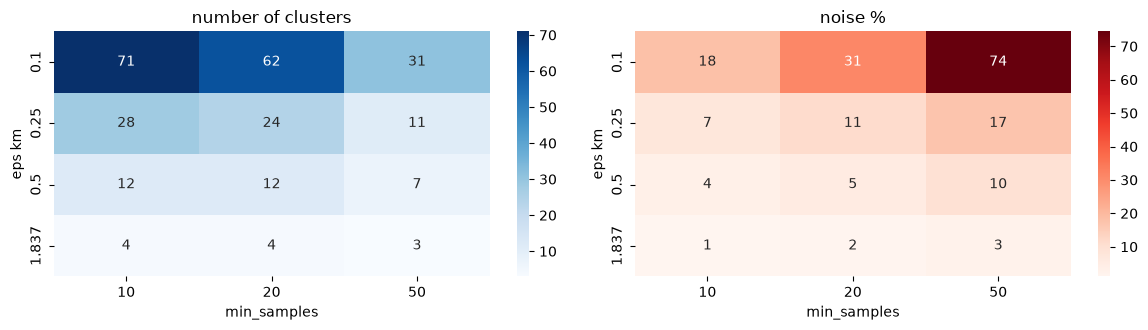

At the knee (eps=1.84 km, min_samples=20): 1.6% noise, but the largest cluster holds 96% of all pickups → the knee answers 'which pickups are in *any* busy area', not 'where are the hotspots'.
Smaller eps or larger min_samples → more clusters and more noise; larger eps → fewer, bigger clusters.


In [6]:
grid_rows = []
for eps in [0.1, 0.25, 0.5, round(eps_knee, 3)]:
    for ms in [10, 20, 50]:
        start = time.perf_counter()
        lab = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_uber)
        seconds = time.perf_counter() - start
        sizes = np.bincount(lab[lab >= 0]) if (lab >= 0).any() else np.array([0])
        grid_rows.append({"eps km": eps, "min_samples": ms, "clusters": int(lab.max() + 1), "noise %": 100 * np.mean(lab == -1),
                          "largest cluster %": 100 * sizes.max() / len(lab), "seconds": seconds})
grid = pd.DataFrame(grid_rows)
print(grid.round(2).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
sns.heatmap(grid.pivot(index="eps km", columns="min_samples", values="clusters"), annot=True, fmt=".0f", cmap="Blues", ax=axes[0])
axes[0].set_title("number of clusters")
sns.heatmap(grid.pivot(index="eps km", columns="min_samples", values="noise %"), annot=True, fmt=".0f", cmap="Reds", ax=axes[1])
axes[1].set_title("noise %")
plt.tight_layout()
plt.show()

knee_row = grid[(grid["eps km"] == round(eps_knee, 3)) & (grid["min_samples"] == MIN_SAMPLES)].iloc[0]
print(f"At the knee (eps={eps_knee:.2f} km, min_samples={MIN_SAMPLES}): {knee_row['noise %']:.1f}% noise, but the largest cluster holds "
      f"{knee_row['largest cluster %']:.0f}% of all pickups → the knee answers 'which pickups are in *any* busy area', not 'where are the hotspots'.")
print("Smaller eps or larger min_samples → more clusters and more noise; larger eps → fewer, bigger clusters.")

### ✍️ Your Turn

Compute the **k-distance** of each point for `k = 2` (the point itself counts as the first neighbour, so this is the distance to the nearest *other* point). Use `NearestNeighbors`. Keep the original order (don't sort).

In [7]:
pts_kd = np.array([[0.0], [1.0], [2.0], [10.0]])
kdist_ex = None  # TODO: NearestNeighbors(n_neighbors=2).fit(...).kneighbors(...) → last column
check("kdist_ex", kdist_ex, [1.0, 1.0, 1.0, 8.0], hint="kneighbors returns (distances, indices); take distances[:, -1].")

⏳ kdist_ex: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
pts_kd = np.array([[0.0], [1.0], [2.0], [10.0]])
distances, _ = NearestNeighbors(n_neighbors=2).fit(pts_kd).kneighbors(pts_kd)
kdist_ex = distances[:, -1]
check("kdist_ex", kdist_ex, [1.0, 1.0, 1.0, 8.0])
```

The point at 10 has a k-distance of 8, far above the others: on a sorted plot it would sit after the knee, so with `eps` around 1 and `min_samples=2` it is noise.
</details>

> 💡 **Interview angle:** "How do you choose eps?" — set `min_samples` first (≥ d+1, often 2·d, larger for noisy data), plot the sorted distance to the `min_samples`-th neighbour and take `eps` at the knee; then check the number of clusters, noise share and the largest cluster, and adjust for the business question. If no single `eps` works, densities vary → HDBSCAN.

## 3. Arbitrary Shapes: DBSCAN vs K-Means 🟢

K-Means cuts space into convex Voronoi cells, so it cannot follow a curve. DBSCAN just follows the chain of dense neighbours, so the shape doesn't matter.

First a **controlled synthetic example** (so we know the true groups): two moons and two nested circles, each with 5% uniformly scattered noise points added.

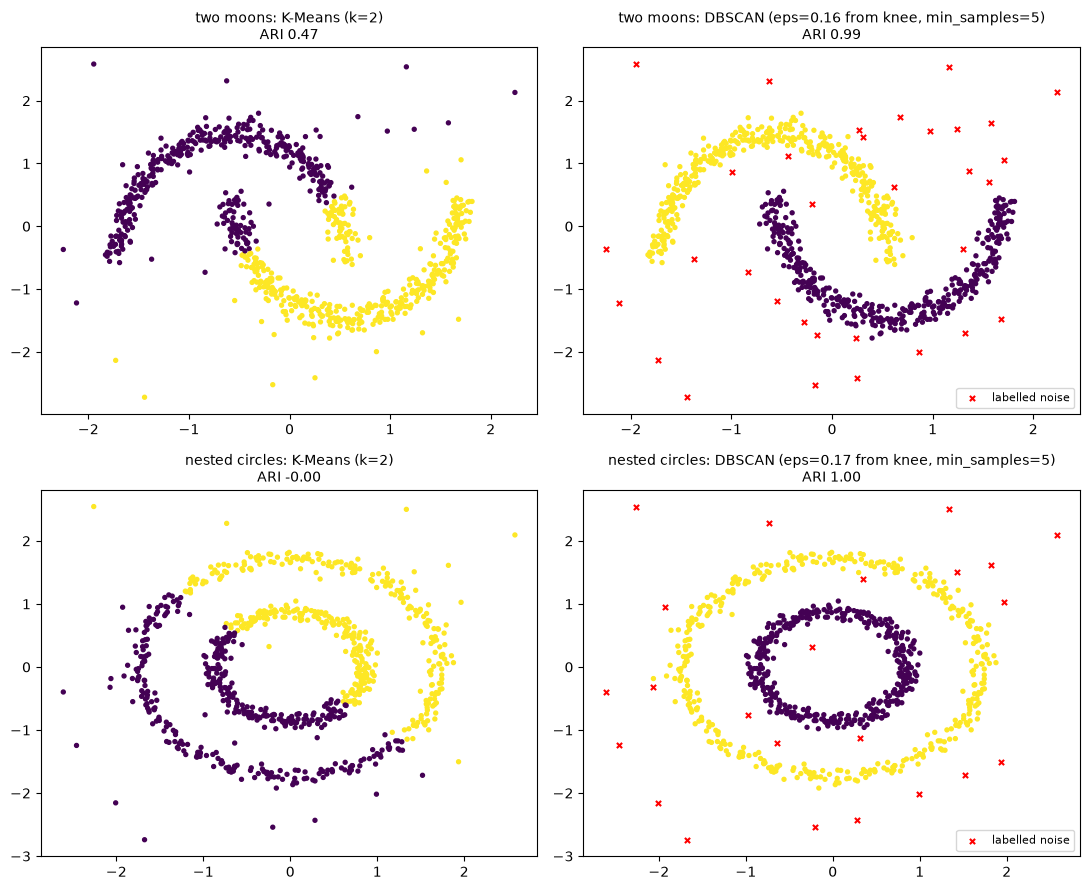

       dataset algorithm  ARI on real points  injected noise flagged %  real points flagged %
     two moons   K-Means               0.469                       0.0                  0.000
     two moons    DBSCAN               0.993                      75.0                  0.375
nested circles   K-Means              -0.001                       0.0                  0.000
nested circles    DBSCAN               1.000                      57.5                  0.000


In [8]:
def with_noise(X, y, frac=0.05, seed=SEED):
    gen = np.random.default_rng(seed)
    n_noise = int(frac * len(X))
    noise = gen.uniform(X.min(axis=0) - 0.5, X.max(axis=0) + 0.5, size=(n_noise, 2))
    return np.vstack([X, noise]), np.concatenate([y, -np.ones(n_noise, dtype=int)])


shape_sets = {"two moons": with_noise(*make_moons(n_samples=800, noise=0.06, random_state=SEED)),
              "nested circles": with_noise(*make_circles(n_samples=800, factor=0.5, noise=0.04, random_state=SEED))}
shape_rows = []
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for row, (name, (Xs, ys)) in enumerate(shape_sets.items()):
    Xs = StandardScaler().fit_transform(Xs)
    eps_s = knee_value(k_distances(Xs, 5))
    labels_by_algo = {"K-Means (k=2)": KMeans(n_clusters=2, n_init=10, random_state=SEED).fit_predict(Xs),
                      f"DBSCAN (eps={eps_s:.2f} from knee, min_samples=5)": DBSCAN(eps=eps_s, min_samples=5).fit_predict(Xs)}
    real = ys >= 0                                                    # the true (non-injected) points
    for col, (algo, lab) in enumerate(labels_by_algo.items()):
        flagged = lab == -1
        shape_rows.append({"dataset": name, "algorithm": algo.split(" (")[0],
                           "ARI on real points": adjusted_rand_score(ys[real], lab[real]),
                           "injected noise flagged %": 100 * flagged[~real].mean(), "real points flagged %": 100 * flagged[real].mean()})
        ax = axes[row, col]
        ax.scatter(*Xs[~flagged].T, c=lab[~flagged], cmap="viridis", s=8)
        ax.scatter(*Xs[flagged].T, c="red", marker="x", s=14, label="labelled noise")
        ax.set_title(f"{name}: {algo}\nARI {shape_rows[-1]['ARI on real points']:.2f}", fontsize=10)
        if flagged.any():
            ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()
shape_table = pd.DataFrame(shape_rows)
print(shape_table.round(3).to_string(index=False))

Now **real data**: 20,000 pickups across New York. We compare K-Means (k = 8) with DBSCAN (eps = 0.25 km, min_samples = 20) and ask two questions: does Manhattan (a long, narrow island) stay together, and do the airports get their own clusters?

K-Means, k=8                           Manhattan landmarks fall in 2 different cluster(s) [0, 0, 2, 2] | JFK cluster 4, LaGuardia cluster 1 | airports separate from Manhattan: True
DBSCAN, eps=0.25 km, min_samples=20    Manhattan landmarks fall in 1 different cluster(s) [0, 0, 0, 0] | JFK cluster 6, LaGuardia cluster 7 | airports separate from Manhattan: True


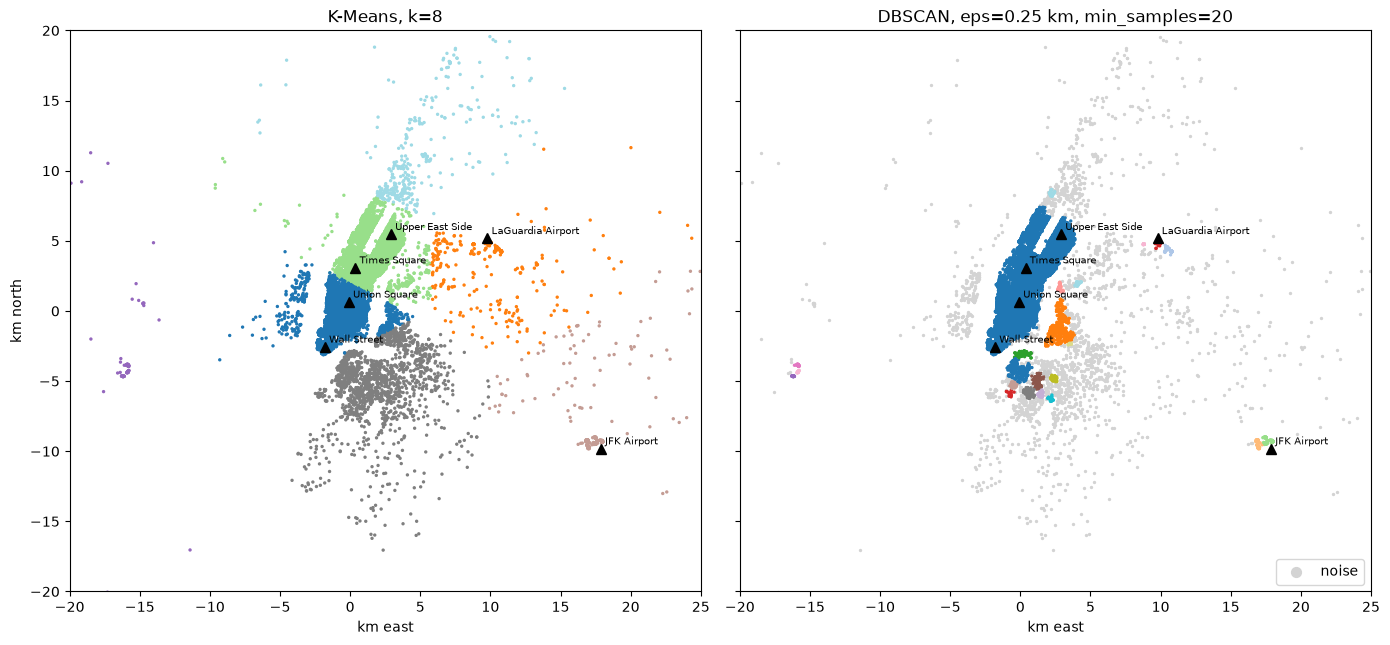

In [9]:
def label_near(labels, X, point_xy, radius=0.4):
    """Most common non-noise label among points within `radius` km of a landmark (None if nothing is there).
    Airports are large, and their pickup kerbs can be ~1 km from the reference coordinate, so we use radius=1.0 for them."""
    near = labels[np.linalg.norm(X - point_xy, axis=1) <= radius]
    near = near[near >= 0]
    return None if len(near) == 0 else int(pd.Series(near).mode().iloc[0])


km8 = KMeans(n_clusters=8, n_init=10, random_state=SEED).fit_predict(X_uber)
db_city = DBSCAN(eps=0.25, min_samples=20).fit_predict(X_uber)
manhattan_marks = ["Wall Street", "Union Square", "Times Square", "Upper East Side"]
fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharex=True, sharey=True)
for ax, (name, lab) in zip(axes, [("K-Means, k=8", km8), ("DBSCAN, eps=0.25 km, min_samples=20", db_city)]):
    ax.scatter(*X_uber[lab == -1].T, c="lightgrey", s=2, label="noise")
    ax.scatter(*X_uber[lab >= 0].T, c=lab[lab >= 0], cmap="tab20", s=2)
    for mark in manhattan_marks + ["JFK Airport", "LaGuardia Airport"]:
        ax.plot(*LANDMARK_XY[mark], "k^", ms=7)
        ax.annotate(mark, LANDMARK_XY[mark], fontsize=7, xytext=(3, 3), textcoords="offset points")
    marks = [label_near(lab, X_uber, LANDMARK_XY[m]) for m in manhattan_marks]
    jfk = label_near(lab, X_uber, LANDMARK_XY["JFK Airport"], radius=1.0)
    lga_lab = label_near(lab, X_uber, LANDMARK_XY["LaGuardia Airport"], radius=1.0)
    ax.set(title=f"{name}", xlabel="km east", xlim=(-20, 25), ylim=(-20, 20), aspect="equal")
    print(f"{name:38s} Manhattan landmarks fall in {len(set(marks))} different cluster(s) {marks} | "
          f"JFK cluster {jfk}, LaGuardia cluster {lga_lab} | airports separate from Manhattan: "
          f"{jfk not in marks and lga_lab not in marks and jfk != lga_lab}")
axes[0].set_ylabel("km north")
axes[1].legend(loc="lower right", markerscale=5)
plt.tight_layout()
plt.show()

K-Means slices the city into cells with straight borders that ignore streets, rivers and the gaps between neighbourhoods, so the continuous Manhattan street grid is cut into pieces, and every far-away pickup is forced into some cell. (The airports are far from everything, so both methods can separate them.) DBSCAN follows the dense street grid, keeps connected busy areas together, and leaves sparse pickups as noise. Keeping all of Manhattan in one cluster is also DBSCAN's limitation: Section 4 shows how to split it.

> 💡 **Interview angle:** "When would you choose DBSCAN over K-Means?" — non-convex or elongated clusters, unknown k, and meaningful noise/outliers, in low-dimensional data such as coordinates. Choose K-Means when clusters are compact, k is known, every point must be assigned, or data is high-dimensional and large.

## 4. Varying Density: OPTICS and HDBSCAN 🟡

**The single-`eps` problem.** Midtown Manhattan has hundreds of pickups per block; Brooklyn streets have a few. A small `eps` finds Manhattan's hotspots but calls Brooklyn noise; a large `eps` keeps Brooklyn but glues Manhattan into one giant blob. No single density threshold fits the whole city.

**OPTICS** (Ankerst et al., 1999) avoids fixing `eps`. It visits points in an order that keeps dense neighbours together and records each point's **reachability distance**:

$$\text{core}_k(p) = \text{distance from } p \text{ to its } k\text{-th neighbour}, \qquad \text{reach}(o \to p) = \max\{\text{core}_k(o),\; d(o, p)\}$$

Plotting reachability in visiting order gives a **reachability plot**: **valleys are clusters**, and deeper valleys are denser clusters. You can cut it at any `eps` to get a DBSCAN-like result (`cluster_optics_dbscan`), or extract clusters by the steepness of the valley walls (`xi`).

**HDBSCAN** (Campello, Moulavi & Sander, 2013) runs DBSCAN for *every* `eps` at once and keeps the best clusters:

1. Compute core distances with `min_samples`, then the **mutual reachability distance** $d_{\text{mreach}}(a, b) = \max\{\text{core}_k(a), \text{core}_k(b), d(a, b)\}$. Sparse points are pushed away from everything.
2. Build a minimum spanning tree on those distances, which gives a single-linkage hierarchy: the DBSCAN result for every `eps`.
3. **Condense** the tree: a split only counts if both sides have at least `min_cluster_size` points.
4. Select clusters: `"eom"` (excess of mass) keeps the most **stable** clusters, those that survive over a long range of densities, and tends to give a few large clusters; `"leaf"` keeps the finest clusters, often better for hotspots.

scikit-learn 1.9's `HDBSCAN` gives `labels_` and `probabilities_` (membership strength, 0–1). You can store `centroids_`/`medoids_` with `store_centers`, and `dbscan_clustering(cut_distance)` cuts the tree at one `eps`. It has **no `predict`**. We set `copy=True` explicitly, because the default of that argument changes in version 1.10.

                          clusters  noise %  largest cluster %  Midtown ≠ Wall St  airports separate  seconds
model                                                                                                        
DBSCAN eps=0.12 (strict)        50    23.84              64.93              False               True     0.04
DBSCAN eps=0.5 (loose)          12     5.44              79.26              False               True     0.12
HDBSCAN eom                      9     6.25              79.36              False               True     0.58
HDBSCAN leaf                    16    64.90               7.58               True               True     0.58


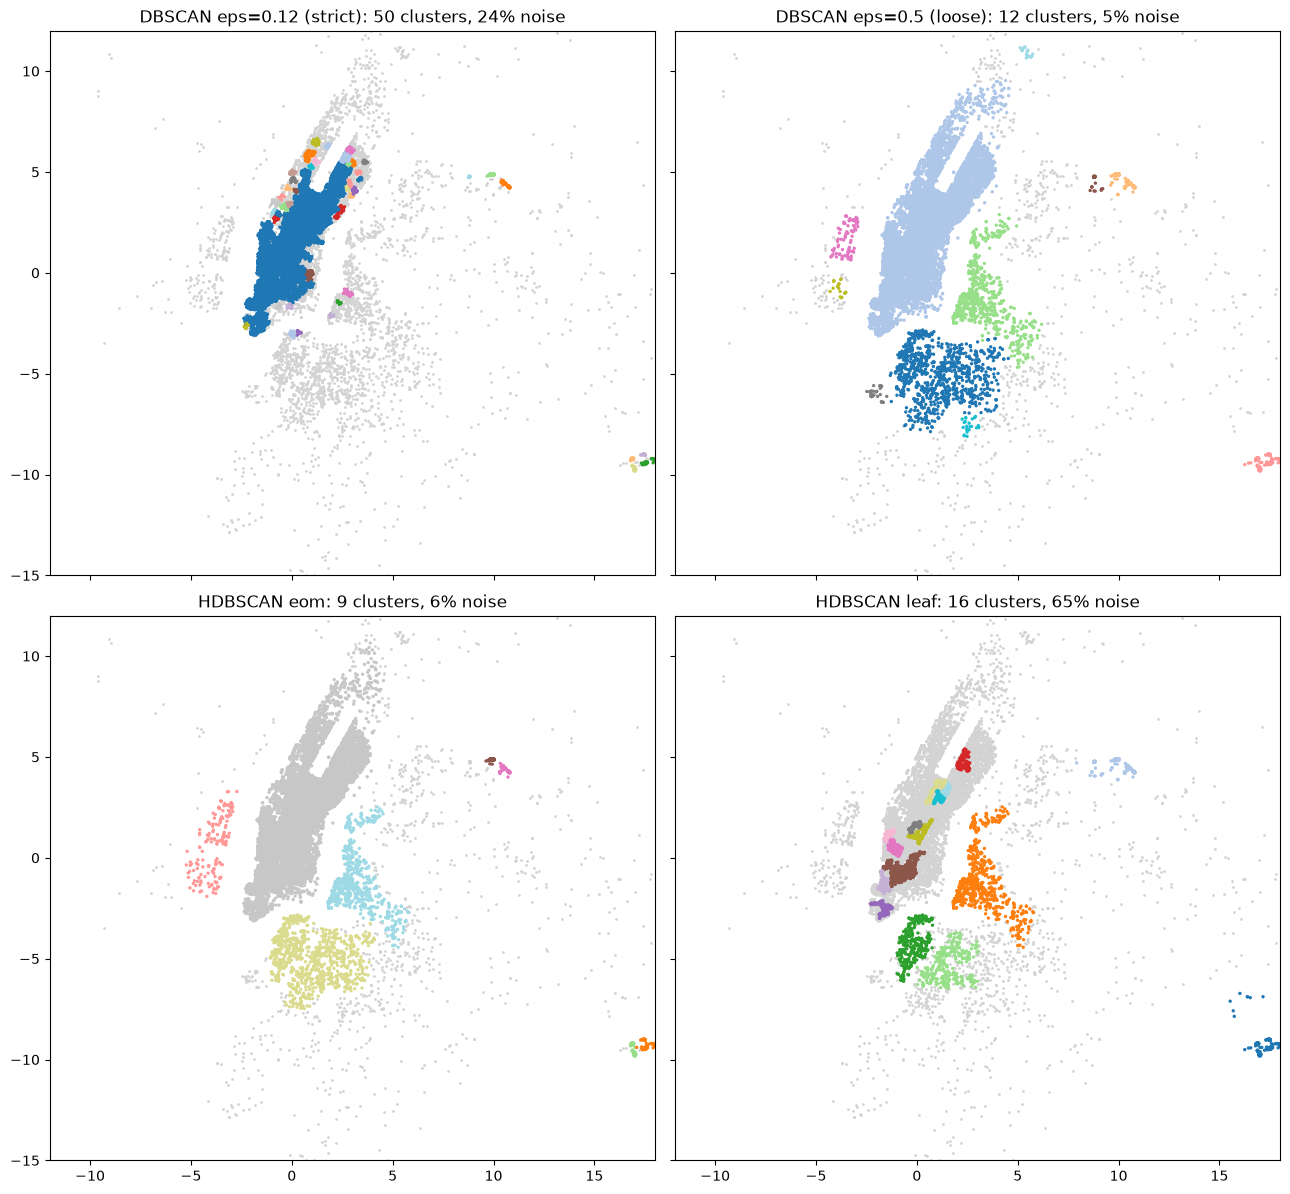

Strict DBSCAN labels 24% of pickups as noise; loose DBSCAN puts 79% into one cluster.
HDBSCAN (leaf) finds 16 clusters with the largest holding only 8% (airports separate: True), with no eps to tune.


In [10]:
density_models = {
    "DBSCAN eps=0.12 (strict)": DBSCAN(eps=0.12, min_samples=MIN_SAMPLES),
    "DBSCAN eps=0.5 (loose)": DBSCAN(eps=0.5, min_samples=MIN_SAMPLES),
    "HDBSCAN eom": HDBSCAN(min_cluster_size=100, min_samples=MIN_SAMPLES, copy=True),
    "HDBSCAN leaf": HDBSCAN(min_cluster_size=200, min_samples=MIN_SAMPLES, cluster_selection_method="leaf", copy=True),
}
density_rows, density_labels = [], {}
for name, model in density_models.items():
    start = time.perf_counter()
    lab = model.fit_predict(X_uber)
    seconds = time.perf_counter() - start
    density_labels[name] = lab
    sizes = np.bincount(lab[lab >= 0])
    marks = [label_near(lab, X_uber, LANDMARK_XY[m], radius=1.0 if "Airport" in m else 0.4)
             for m in ["Times Square", "Wall Street", "JFK Airport", "LaGuardia Airport"]]
    density_rows.append({"model": name, "clusters": int(lab.max() + 1), "noise %": 100 * np.mean(lab == -1),
                         "largest cluster %": 100 * sizes.max() / len(lab), "Midtown ≠ Wall St": marks[0] != marks[1],
                         "airports separate": None not in marks[2:] and len({marks[0], marks[2], marks[3]}) == 3, "seconds": seconds})
density_table = pd.DataFrame(density_rows).set_index("model")
print(density_table.round(2))

fig, axes = plt.subplots(2, 2, figsize=(13, 12), sharex=True, sharey=True)
for ax, (name, lab) in zip(axes.ravel(), density_labels.items()):
    ax.scatter(*X_uber[lab == -1].T, c="lightgrey", s=1)
    ax.scatter(*X_uber[lab >= 0].T, c=lab[lab >= 0] % 20, cmap="tab20", s=2)
    ax.set(title=f"{name}: {density_table.loc[name, 'clusters']} clusters, {density_table.loc[name, 'noise %']:.0f}% noise",
           xlim=(-12, 18), ylim=(-15, 12), aspect="equal")
plt.tight_layout()
plt.show()

strict, loose = density_table.loc["DBSCAN eps=0.12 (strict)"], density_table.loc["DBSCAN eps=0.5 (loose)"]
leaf = density_table.loc["HDBSCAN leaf"]
print(f"Strict DBSCAN labels {strict['noise %']:.0f}% of pickups as noise; loose DBSCAN puts {loose['largest cluster %']:.0f}% into one cluster.")
print(f"HDBSCAN (leaf) finds {leaf['clusters']} clusters with the largest holding only {leaf['largest cluster %']:.0f}% "
      f"(airports separate: {leaf['airports separate']}), with no eps to tune.")

**OPTICS** on 8,000 of the pickups (OPTICS is noticeably slower in scikit-learn). The reachability plot shows valleys of very different depths, which is exactly the varying-density situation. Cutting it at `eps = 0.25` reproduces DBSCAN.

OPTICS on 8,000 points: 2.0s | xi clusters: 10, noise 87%
OPTICS cut at eps=0.25 vs DBSCAN(eps=0.25): ARI 0.997, same noise points: 99.7%


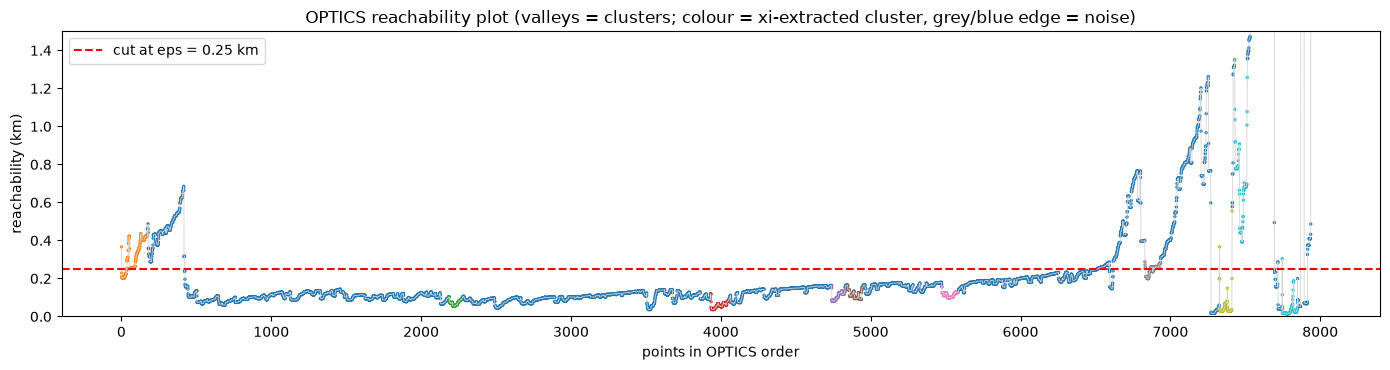

HDBSCAN.dbscan_clustering(cut_distance=0.25) vs DBSCAN(eps=0.25) on all 20k: ARI 0.964 (it cuts the mutual-reachability tree, DBSCAN*, which has no border points, so it isn't identical)


In [11]:
X_opt = X_uber[:8000]
start = time.perf_counter()
optics = OPTICS(min_samples=MIN_SAMPLES, xi=0.05, min_cluster_size=0.01).fit(X_opt)
optics_s = time.perf_counter() - start
reach_ordered = optics.reachability_[optics.ordering_]
labels_ordered = optics.labels_[optics.ordering_]
cut_labels = cluster_optics_dbscan(reachability=optics.reachability_, core_distances=optics.core_distances_,
                                   ordering=optics.ordering_, eps=0.25)
direct_labels = DBSCAN(eps=0.25, min_samples=MIN_SAMPLES).fit_predict(X_opt)
print(f"OPTICS on {len(X_opt):,} points: {optics_s:.1f}s | xi clusters: {optics.labels_.max() + 1}, noise {np.mean(optics.labels_ == -1):.0%}")
print(f"OPTICS cut at eps=0.25 vs DBSCAN(eps=0.25): ARI {adjusted_rand_score(direct_labels, cut_labels):.3f}, "
      f"same noise points: {np.mean((cut_labels == -1) == (direct_labels == -1)):.1%}")

fig, ax = plt.subplots(figsize=(14, 3.8))
finite = np.where(np.isinf(reach_ordered), np.nan, reach_ordered)
ax.plot(np.arange(len(finite)), finite, color="lightgrey", lw=0.6)
ax.scatter(np.arange(len(finite)), finite, c=np.where(labels_ordered >= 0, labels_ordered, -1), cmap="tab10", s=2)
ax.axhline(0.25, color="red", ls="--", label="cut at eps = 0.25 km")
ax.set(title="OPTICS reachability plot (valleys = clusters; colour = xi-extracted cluster, grey/blue edge = noise)",
       xlabel="points in OPTICS order", ylabel="reachability (km)", ylim=(0, 1.5))
ax.legend()
plt.tight_layout()
plt.show()

hdb_leaf = density_models["HDBSCAN leaf"]
star_labels = hdb_leaf.dbscan_clustering(cut_distance=0.25, min_cluster_size=MIN_SAMPLES)
print(f"HDBSCAN.dbscan_clustering(cut_distance=0.25) vs DBSCAN(eps=0.25) on all 20k: "
      f"ARI {adjusted_rand_score(DBSCAN(eps=0.25, min_samples=MIN_SAMPLES).fit_predict(X_uber), star_labels):.3f} "
      f"(it cuts the mutual-reachability tree, DBSCAN*, which has no border points, so it isn't identical)")

### ✍️ Your Turn

Compute the **mutual reachability distance** between points `a` and `b` for two cases. Core distances: `core_a = 0.4`, `core_b = 1.0`. Actual distances: `0.7` in case 1 and `1.5` in case 2. Return an array with both answers.

In [12]:
core_a, core_b = 0.4, 1.0
d_ab = np.array([0.7, 1.5])
mreach = None  # TODO: element-wise max of core_a, core_b and d_ab
check("mreach", mreach, [1.0, 1.5], hint="np.maximum(np.maximum(core_a, core_b), d_ab)")

⏳ mreach: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
core_a, core_b = 0.4, 1.0
d_ab = np.array([0.7, 1.5])
mreach = np.maximum(max(core_a, core_b), d_ab)
check("mreach", mreach, [1.0, 1.5])
```

In case 1, `b` lives in a sparse area (core distance 1.0), so even though `a` is only 0.7 away, the pair is treated as 1.0 apart. That is how HDBSCAN stops sparse points from bridging dense clusters.
</details>

> 💡 **Interview angle:** "DBSCAN struggles with varying density — what do you do?" — explain why one `eps` can't fit dense and sparse regions, then offer OPTICS (reachability plot, extract at several levels) or HDBSCAN (hierarchy over all `eps` using mutual reachability, keeps the most stable clusters, needs mainly `min_cluster_size`). Mention `eom` vs `leaf` selection.

## 5. Handling Noise 🟡

Noise (`-1`) is a feature, not a bug, but downstream code must decide what to do with it:

| Option | When |
|---|---|
| **Report it** (share of noise, where it is) | always: a sudden jump in noise share is a data or drift signal |
| **Keep it as its own group** ("unassigned") | dashboards, hotspot maps |
| **Treat it as anomalies** | fraud, sensor faults, unusual trips |
| **Assign new points like DBSCAN would**: the label of the nearest **core** point if it is within `eps`, else noise | scoring new data without refitting |
| **Soft membership** with HDBSCAN's `probabilities_` | separate strong members from weak edge members |

Noise also explains why K-Means struggles on real data: it *must* place every outlier in some cluster, and squared distances make far-away points very expensive.

In [13]:
db_model = DBSCAN(eps=0.25, min_samples=MIN_SAMPLES).fit(X_uber)
labels_db = db_model.labels_


def dbscan_assign(model, X_train, X_new):
    """Label new points with the cluster of the nearest core point within eps (DBSCAN's border rule), else -1."""
    core_X = X_train[model.core_sample_indices_]
    core_labels = model.labels_[model.core_sample_indices_]
    dist, idx = NearestNeighbors(n_neighbors=1).fit(core_X).kneighbors(X_new)
    return np.where(dist[:, 0] <= model.eps, core_labels[idx[:, 0]], -1)


replayed = dbscan_assign(db_model, X_uber, X_uber)
core_idx = db_model.core_sample_indices_
assert np.array_equal(replayed[core_idx], labels_db[core_idx])
print(f"✅ assigning the training core points reproduces their labels; all training points agree {np.mean(replayed == labels_db):.2%} "
      "(border points touching two clusters may pick either)")

other_idx = rng.choice(np.setdiff1d(np.arange(len(uber)), sample_idx), size=5000, replace=False)
new_labels = dbscan_assign(db_model, X_uber, uber_xy_all[other_idx])
train_share = pd.Series(labels_db).value_counts(normalize=True)
new_share = pd.Series(new_labels).value_counts(normalize=True).reindex(train_share.index, fill_value=0)
print(f"5,000 unseen pickups: {np.mean(new_labels == -1):.1%} noise (training: {np.mean(labels_db == -1):.1%}); "
      f"correlation of cluster shares with training: {np.corrcoef(train_share, new_share)[0, 1]:.3f}")

✅ assigning the training core points reproduces their labels; all training points agree 99.96% (border points touching two clusters may pick either)
5,000 unseen pickups: 11.5% noise (training: 11.3%); correlation of cluster shares with training: 1.000


DBSCAN noise is 11.3% of the pickups but 66.4% of K-Means' inertia.
Refitting K-Means without the noise moves the matched centroids by a median of 1.66 km (max 45.95 km).
HDBSCAN (leaf) membership strength of clustered points: median 1.00; 4% are weak members (probability < 0.5)


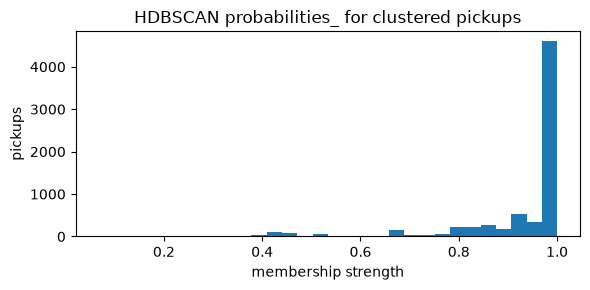

In [14]:
noise = labels_db == -1
km10 = KMeans(n_clusters=10, n_init=10, random_state=SEED).fit(X_uber)
sq_err = ((X_uber - km10.cluster_centers_[km10.labels_]) ** 2).sum(axis=1)
km10_clean = KMeans(n_clusters=10, n_init=10, random_state=SEED).fit(X_uber[~noise])
centroid_dist = np.linalg.norm(km10.cluster_centers_[:, None] - km10_clean.cluster_centers_[None], axis=2)
row_ind, col_ind = linear_sum_assignment(centroid_dist)          # match the two sets of centroids one-to-one
shifts = centroid_dist[row_ind, col_ind]
print(f"DBSCAN noise is {noise.mean():.1%} of the pickups but {sq_err[noise].sum() / sq_err.sum():.1%} of K-Means' inertia.")
print(f"Refitting K-Means without the noise moves the matched centroids by a median of {np.median(shifts):.2f} km (max {shifts.max():.2f} km).")

probs = hdb_leaf.probabilities_[hdb_leaf.labels_ >= 0]
print(f"HDBSCAN (leaf) membership strength of clustered points: median {np.median(probs):.2f}; "
      f"{np.mean(probs < 0.5):.0%} are weak members (probability < 0.5)")
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(probs, bins=30)
ax.set(title="HDBSCAN probabilities_ for clustered pickups", xlabel="membership strength", ylabel="pickups")
plt.tight_layout()
plt.show()

### ✍️ Your Turn

Assign the `new_points` with DBSCAN's rule: take the label of the nearest core point **if it is within `eps`**, otherwise `-1`.

In [15]:
core_points = np.array([[0.0, 0.0], [5.0, 5.0]])
core_point_labels = np.array([0, 1])
eps_rule = 1.0
new_points = np.array([[0.5, 0.5], [5.0, 4.2], [3.0, 3.0]])
assigned = None  # TODO
check("assigned", assigned, [0, 1, -1], hint="Distances (3, 2) → argmin and min per row → np.where(min <= eps, label, -1).")

⏳ assigned: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
core_points = np.array([[0.0, 0.0], [5.0, 5.0]])
core_point_labels = np.array([0, 1])
eps_rule = 1.0
new_points = np.array([[0.5, 0.5], [5.0, 4.2], [3.0, 3.0]])
dist = np.linalg.norm(new_points[:, None, :] - core_points[None, :, :], axis=2)
assigned = np.where(dist.min(axis=1) <= eps_rule, core_point_labels[dist.argmin(axis=1)], -1)
check("assigned", assigned, [0, 1, -1])
```

`[3, 3]` is 2.83 from the nearest core point, beyond `eps`, so it stays noise. It would *not* become noise with K-Means, which always assigns.
</details>

> 💡 **Interview angle:** "DBSCAN has no predict — how do you score new data?" — assign each new point to the cluster of its nearest core point if within `eps`, else noise (exactly the border rule), or refit periodically; with the `hdbscan` package use `approximate_predict`. And monitor the noise share over time as a drift signal.

## 6. Gaussian Mixture Models: Soft Clustering 🟢

A **Gaussian mixture model** tells a story about how the data was generated:

1. Pick a component $k$ with probability $\pi_k$ (the **mixing weights**, $\sum_k \pi_k = 1$).
2. Draw the point from that component's normal distribution $\mathcal{N}(\mu_k, \Sigma_k)$: centre $\mu_k$, shape and orientation $\Sigma_k$ (the covariance matrix).

So the density of the data is a weighted sum of bells:

$$p(x) = \sum_{k=1}^{K} \pi_k \, \mathcal{N}(x \mid \mu_k, \Sigma_k)$$

**Soft assignment** is just Bayes' rule (from the statistics notebook): the probability that point $x_i$ came from component $k$ is its **responsibility**

$$\gamma_{ik} = P(z_i = k \mid x_i) = \frac{\pi_k \, \mathcal{N}(x_i \mid \mu_k, \Sigma_k)}{\sum_{j} \pi_j \, \mathcal{N}(x_i \mid \mu_j, \Sigma_j)}$$

`predict_proba` returns the $\gamma_{ik}$; `predict` returns the most likely component. Compared with K-Means, a GMM can model **elliptical** clusters with **different sizes and weights**, and it tells you how **sure** it is.

Let's use two penguin measurements, bill length and bill depth, where the three species form tilted, overlapping ellipses.

In [16]:
penguins = sns.load_dataset("penguins", data_home=str(OUTPUT_DIR / "seaborn-data")).dropna().reset_index(drop=True)
PENGUIN_FEATURES = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
species = penguins["species"].to_numpy()
X_pen2 = StandardScaler().fit_transform(penguins[["bill_length_mm", "bill_depth_mm"]])

gmm2 = GaussianMixture(n_components=3, covariance_type="full", n_init=5, random_state=SEED).fit(X_pen2)
km_pen2 = KMeans(n_clusters=3, n_init=10, random_state=SEED).fit(X_pen2)
proba2 = gmm2.predict_proba(X_pen2)
confidence = proba2.max(axis=1)
uncertain = confidence < 0.8
print(f"ARI vs species — K-Means: {adjusted_rand_score(species, km_pen2.labels_):.3f} | GMM: {adjusted_rand_score(species, gmm2.predict(X_pen2)):.3f}")
print(f"mixing weights π: {gmm2.weights_.round(3)} (share of penguins per component)")
print(f"{uncertain.sum()} penguins have max probability < 0.8; their species: {pd.Series(species[uncertain]).value_counts().to_dict()}")
most_uncertain = np.argsort(confidence)[:5]
print(pd.DataFrame(proba2[most_uncertain].round(3), columns=[f"P(component {k})" for k in range(3)])
      .assign(species=species[most_uncertain], bill_length=penguins.loc[most_uncertain, "bill_length_mm"].to_numpy(),
              bill_depth=penguins.loc[most_uncertain, "bill_depth_mm"].to_numpy()))


def full_covariances(gmm):
    """Covariance matrices as (k, d, d) whatever the covariance_type."""
    k, d = gmm.means_.shape
    if gmm.covariance_type == "full":
        return gmm.covariances_
    if gmm.covariance_type == "tied":
        return np.repeat(gmm.covariances_[None], k, axis=0)
    if gmm.covariance_type == "diag":
        return np.array([np.diag(c) for c in gmm.covariances_])
    return np.array([np.eye(d) * c for c in gmm.covariances_])


def draw_ellipses(ax, means, covs, colors=None):
    """1- and 2-standard-deviation ellipses of 2-D Gaussians."""
    for k, (mean, cov) in enumerate(zip(means, covs)):
        vals, vecs = np.linalg.eigh(cov)                       # ascending eigenvalues
        angle = np.degrees(np.arctan2(vecs[1, -1], vecs[0, -1]))
        for n_std in (1, 2):
            ax.add_patch(Ellipse(mean, 2 * n_std * np.sqrt(vals[-1]), 2 * n_std * np.sqrt(vals[0]), angle=angle,
                                 fill=False, lw=1.5, color="black" if colors is None else colors[k], alpha=0.8 if n_std == 1 else 0.4))

ARI vs species — K-Means: 0.820 | GMM: 0.909
mixing weights π: [0.456 0.194 0.351] (share of penguins per component)
14 penguins have max probability < 0.8; their species: {'Chinstrap': 7, 'Gentoo': 5, 'Adelie': 2}
   P(component 0)  P(component 1)  P(component 2)    species  bill_length  bill_depth
0           0.476           0.524           0.000  Chinstrap         45.4        18.7
1           0.401           0.599           0.000     Adelie         45.8        18.9
2           0.377           0.621           0.002  Chinstrap         43.2        16.6
3           0.000           0.648           0.352     Gentoo         50.8        17.3
4           0.676           0.324           0.000     Adelie         44.1        18.0


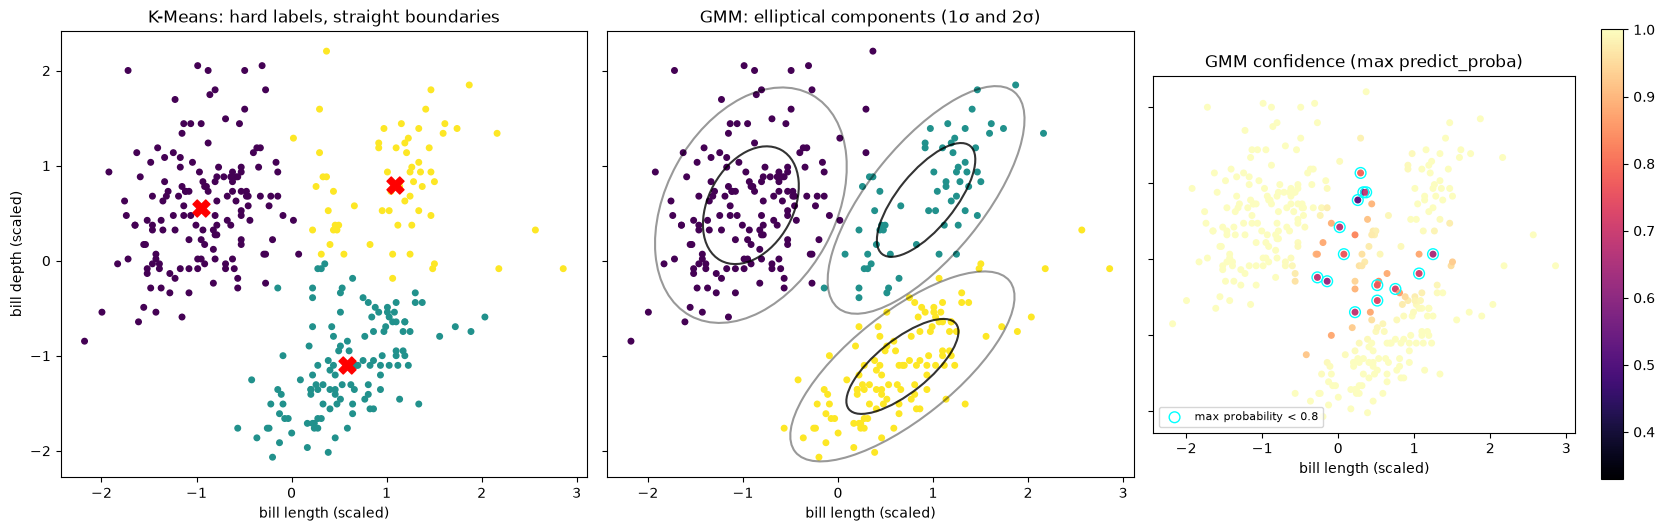

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharex=True, sharey=True)
axes[0].scatter(*X_pen2.T, c=km_pen2.labels_, cmap="viridis", s=16)
axes[0].scatter(*km_pen2.cluster_centers_.T, c="red", marker="X", s=150)
axes[0].set(title="K-Means: hard labels, straight boundaries")
axes[1].scatter(*X_pen2.T, c=gmm2.predict(X_pen2), cmap="viridis", s=16)
draw_ellipses(axes[1], gmm2.means_, full_covariances(gmm2))
axes[1].set(title="GMM: elliptical components (1σ and 2σ)")
sc = axes[2].scatter(*X_pen2.T, c=confidence, cmap="magma", s=16, vmin=0.33, vmax=1)
axes[2].scatter(*X_pen2[uncertain].T, facecolors="none", edgecolors="cyan", s=60, label="max probability < 0.8")
axes[2].set(title="GMM confidence (max predict_proba)")
axes[2].legend(loc="lower left", fontsize=8)
fig.colorbar(sc, ax=axes[2])
for ax in axes:
    ax.set(xlabel="bill length (scaled)", aspect="equal")
axes[0].set_ylabel("bill depth (scaled)")
plt.tight_layout()
plt.show()

The uncertain penguins sit where two ellipses overlap. A hard clustering would hide that doubt; a GMM makes it explicit, which is useful when a wrong assignment is costly.

### ✍️ Your Turn

A 1-D mixture has two components with equal weights $\pi = [0.5, 0.5]$, means $[0, 2]$ and standard deviations $[1, 1]$. Compute the **responsibilities** of the point $x = 0.5$ with `scipy.stats.norm.pdf`.

In [18]:
x_point = 0.5
weights_1d, means_1d, stds_1d = np.array([0.5, 0.5]), np.array([0.0, 2.0]), np.array([1.0, 1.0])
responsibilities = None  # TODO: weighted densities, normalized to sum to 1
check("responsibilities", responsibilities, [0.731059, 0.268941], hint="w = weights_1d * norm.pdf(x_point, means_1d, stds_1d); w / w.sum()")

⏳ responsibilities: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
x_point = 0.5
weights_1d, means_1d, stds_1d = np.array([0.5, 0.5]), np.array([0.0, 2.0]), np.array([1.0, 1.0])
weighted = weights_1d * norm.pdf(x_point, means_1d, stds_1d)
responsibilities = weighted / weighted.sum()
check("responsibilities", responsibilities, [0.731059, 0.268941])
```

With equal variances the answer simplifies to a logistic function of the distance difference: $1 / (1 + e^{-1}) \approx 0.731$. That's why GMM boundaries with shared covariance are linear (like LDA), and curved (quadratic) otherwise.
</details>

> 💡 **Interview angle:** "GMM vs K-Means?" — K-Means gives hard labels and implicitly assumes equal, spherical clusters; a GMM models each cluster as a Gaussian with its own weight, mean and covariance, gives probabilities via Bayes' rule, and is a density model (likelihood, BIC, sampling). K-Means is the limit of a GMM with equal spherical covariances $\sigma^2 I$ as $\sigma \to 0$.

## 7. The EM Algorithm 🟡

We want parameters $\theta = \{\pi_k, \mu_k, \Sigma_k\}$ that maximize the **log-likelihood**

$$\ell(\theta) = \sum_{i=1}^{n} \log \sum_{k=1}^{K} \pi_k\, \mathcal{N}(x_i \mid \mu_k, \Sigma_k)$$

The log of a sum has no closed-form maximum. But **if we knew which component generated each point**, each component would just be a normal distribution fitted to its own points: easy. **EM (Expectation–Maximization;** Dempster, Laird & Rubin, 1977**)** alternates between guessing the memberships and refitting:

**E-step (Expectation) — "who belongs where, softly?"** With the current parameters, compute responsibilities
$$\gamma_{ik} = \frac{\pi_k \mathcal{N}(x_i \mid \mu_k, \Sigma_k)}{\sum_j \pi_j \mathcal{N}(x_i \mid \mu_j, \Sigma_j)}$$

**M-step (Maximization) — "refit each Gaussian with those soft weights."** With $N_k = \sum_i \gamma_{ik}$ (the effective number of points in component $k$):
$$\pi_k = \frac{N_k}{n}, \qquad \mu_k = \frac{1}{N_k}\sum_i \gamma_{ik}\, x_i, \qquad \Sigma_k = \frac{1}{N_k}\sum_i \gamma_{ik}\,(x_i - \mu_k)(x_i - \mu_k)^\top \;(+\ \text{reg\_covar}\cdot I)$$

These are just the weighted versions of "share of points", "mean" and "covariance".

**Why the likelihood never goes down.** For any distribution over memberships, Jensen's inequality gives a lower bound on $\ell(\theta)$ (the *evidence lower bound*). The E-step makes the bound touch $\ell$ at the current $\theta$. The M-step maximizes the bound, so $\ell$ can only increase. EM therefore converges, but to a **local** maximum, so initialization matters (`n_init`; scikit-learn initializes with K-Means by default).

**Two practical traps:** (1) a component can collapse onto one point, its variance goes to 0 and the likelihood to infinity, so `reg_covar` adds a tiny constant to the diagonal; (2) with hard 0/1 responsibilities and fixed equal spherical covariances, EM becomes exactly K-Means.

Let's watch EM from a deliberately poor start: three Adelie penguins as the means, small round covariances, equal weights. We stop EM after 1, 2, … iterations on purpose to see its progress.

✅ mean log-likelihood never decreased: [-5.0618 -2.7672 -2.7465 -2.7254 -2.5344 -2.428  -2.4238]


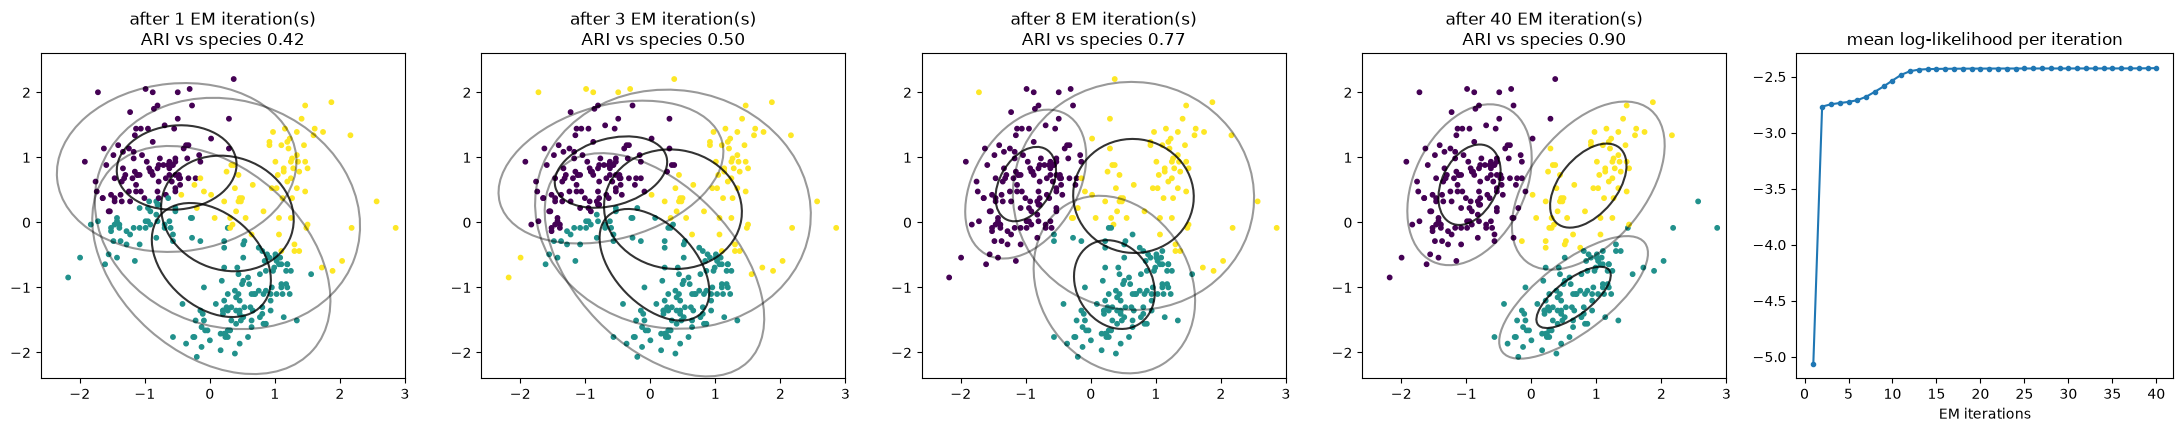

In [19]:
init_means = X_pen2[[0, 1, 2]]                              # three Adelie penguins: a poor start
init_precisions = np.repeat(np.eye(2)[None] / 0.3, 3, axis=0)   # round covariances 0.3·I  → precision = inverse
ll_by_iter, em_frames = [], {}
for n_iter in range(1, 41):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", ConvergenceWarning)    # stopping early is intentional here
        g = GaussianMixture(n_components=3, covariance_type="full", weights_init=np.full(3, 1 / 3), means_init=init_means,
                            precisions_init=init_precisions, max_iter=n_iter, tol=1e-10, random_state=SEED).fit(X_pen2)
    ll_by_iter.append(g.lower_bound_)                       # mean log-likelihood per point at the last E-step
    if n_iter in (1, 3, 8, 40):
        em_frames[n_iter] = g
ll_by_iter = np.array(ll_by_iter)
assert np.all(np.diff(ll_by_iter) >= -1e-9), "log-likelihood decreased"
print("✅ mean log-likelihood never decreased:", ll_by_iter[[0, 1, 2, 4, 9, 19, 39]].round(4))

fig, axes = plt.subplots(1, 5, figsize=(22, 4.2))
for ax, (n_iter, g) in zip(axes, em_frames.items()):
    ax.scatter(*X_pen2.T, c=g.predict(X_pen2), cmap="viridis", s=10)
    draw_ellipses(ax, g.means_, full_covariances(g))
    ax.set(title=f"after {n_iter} EM iteration(s)\nARI vs species {adjusted_rand_score(species, g.predict(X_pen2)):.2f}",
           xlim=(-2.6, 3), ylim=(-2.4, 2.6), aspect="equal")
axes[4].plot(np.arange(1, 41), ll_by_iter, "o-", ms=3)
axes[4].set(title="mean log-likelihood per iteration", xlabel="EM iterations")
plt.tight_layout()
plt.show()

### ✍️ Your Turn

Do one **M-step** by hand for a 1-D component A. The points are `x = [0, 1, 2, 10]` and A's responsibilities are `[1.0, 1.0, 0.5, 0.0]`. Compute its new weight $\pi_A = N_A / n$, mean and variance (weighted, divide by $N_A$). Return a dict.

In [20]:
x_m = np.array([0.0, 1.0, 2.0, 10.0])
gamma_A = np.array([1.0, 1.0, 0.5, 0.0])
m_step_A = None  # TODO: {"weight": ..., "mean": ..., "var": ...}
check("m_step_A", m_step_A, {"weight": 0.625, "mean": 0.8, "var": 0.56}, hint="N_A = gamma_A.sum() = 2.5; mean = (gamma_A * x_m).sum() / N_A.")

⏳ m_step_A: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
x_m = np.array([0.0, 1.0, 2.0, 10.0])
gamma_A = np.array([1.0, 1.0, 0.5, 0.0])
N_A = gamma_A.sum()
mean_A = (gamma_A * x_m).sum() / N_A
m_step_A = {"weight": N_A / len(x_m), "mean": mean_A, "var": (gamma_A * (x_m - mean_A) ** 2).sum() / N_A}
check("m_step_A", m_step_A, {"weight": 0.625, "mean": 0.8, "var": 0.56})
```

The point at 2 counts as half a point for A, and the point at 10 not at all.
</details>

> 💡 **Interview angle:** "Explain EM for Gaussian mixtures." — E-step: compute each point's responsibilities with Bayes' rule under the current parameters; M-step: re-estimate weights, means and covariances as responsibility-weighted averages. The log-likelihood never decreases (lower-bound argument), converges to a local optimum, needs good initialization (K-Means, `n_init`) and `reg_covar` against collapsing components.

## 8. Covariance Types and Choosing Components with BIC/AIC 🟡

`covariance_type` controls how flexible each Gaussian's shape is, and therefore how many parameters the model has ($k$ components, $d$ features):

| `covariance_type` | Shape of each component | Covariance parameters |
|---|---|---|
| `"full"` | any ellipse, own orientation per component | $k \cdot d(d+1)/2$ |
| `"tied"` | all components share **one** ellipse | $d(d+1)/2$ |
| `"diag"` | axis-aligned ellipses, own per component | $k \cdot d$ |
| `"spherical"` | circles, own radius per component | $k$ |

Plus $k \cdot d$ means and $k - 1$ free weights. More parameters always fit the training data better, so we penalize complexity:

$$\text{BIC} = -2\,\log L + p \ln n, \qquad \text{AIC} = -2\,\log L + 2p$$

where $\log L$ is the total log-likelihood, $p$ the number of parameters, and $n$ the number of rows. **Lower is better.** BIC's penalty $\ln n$ exceeds AIC's 2 once $n \ge 8$, so BIC picks **smaller** models. It's consistent (it finds the true model as $n$ grows, if the true model is in the list). AIC aims at the best predictive density and tolerates bigger models.

We fit all 4 covariance types × $k = 1 … 7$ on the four scaled penguin measurements.

In [21]:
X_pen4 = StandardScaler().fit_transform(penguins[PENGUIN_FEATURES])


def n_gmm_parameters(k, d, cov_type):
    cov = {"full": k * d * (d + 1) / 2, "tied": d * (d + 1) / 2, "diag": k * d, "spherical": k}[cov_type]
    return int(k * d + cov + (k - 1))


bic_rows, bic_models = [], {}
for cov_type in ["full", "tied", "diag", "spherical"]:
    for k in range(1, 8):
        g = GaussianMixture(n_components=k, covariance_type=cov_type, n_init=5, random_state=SEED).fit(X_pen4)
        bic_models[(cov_type, k)] = g
        bic_rows.append({"covariance": cov_type, "k": k, "params": n_gmm_parameters(k, 4, cov_type),
                         "BIC": g.bic(X_pen4), "AIC": g.aic(X_pen4),
                         "ARI vs species": adjusted_rand_score(species, g.predict(X_pen4)) if k > 1 else np.nan})
bic_table = pd.DataFrame(bic_rows)
print("BIC:\n", bic_table.pivot(index="k", columns="covariance", values="BIC").round(0))
print("\nARI vs species (hidden):\n", bic_table.pivot(index="k", columns="covariance", values="ARI vs species").round(3))

best_bic = bic_table.loc[bic_table["BIC"].idxmin()]
best_aic = bic_table.loc[bic_table["AIC"].idxmin()]
best_ari = bic_table.loc[bic_table["ARI vs species"].idxmax()]
chosen = bic_models[(best_bic["covariance"], best_bic["k"])]
log_l = chosen.score(X_pen4) * len(X_pen4)                   # score() is the MEAN log-likelihood per row
p = n_gmm_parameters(best_bic["k"], 4, best_bic["covariance"])
assert np.isclose(-2 * log_l + p * np.log(len(X_pen4)), chosen.bic(X_pen4))
print(f"\n✅ BIC by hand = -2·logL + p·ln(n) = {-2 * log_l:.1f} + {p}·ln({len(X_pen4)}) = {chosen.bic(X_pen4):.1f}")
print(f"Best BIC: {best_bic['covariance']} k={best_bic['k']} (ARI {best_bic['ARI vs species']:.3f}) | "
      f"best AIC: {best_aic['covariance']} k={best_aic['k']} (ARI {best_aic['ARI vs species']:.3f}) | "
      f"best ARI: {best_ari['covariance']} k={best_ari['k']} ({best_ari['ARI vs species']:.3f})")

BIC:
 covariance    diag    full  spherical    tied
k                                            
1           3827.0  3040.0     3809.0  3040.0
2           2957.0  2524.0     3070.0  2599.0
3           2818.0  2495.0     2858.0  2456.0
4           2630.0  2541.0     2653.0  2442.0
5           2612.0  2602.0     2570.0  2459.0
6           2611.0  2658.0     2538.0  2470.0
7           2599.0  2719.0     2517.0  2487.0

ARI vs species (hidden):
 covariance   diag   full  spherical   tied
k                                         
1             NaN    NaN        NaN    NaN
2           0.649  0.649      0.649  0.649
3           0.617  0.959      0.819  0.959
4           0.456  0.816      0.666  0.758
5           0.401  0.594      0.574  0.717
6           0.541  0.549      0.536  0.520
7           0.480  0.502      0.480  0.506

✅ BIC by hand = -2·logL + p·ln(n) = 2273.6 + 29·ln(333) = 2442.0
Best BIC: tied k=4 (ARI 0.758) | best AIC: full k=4 (ARI 0.816) | best ARI: tied k=3 (0.959)


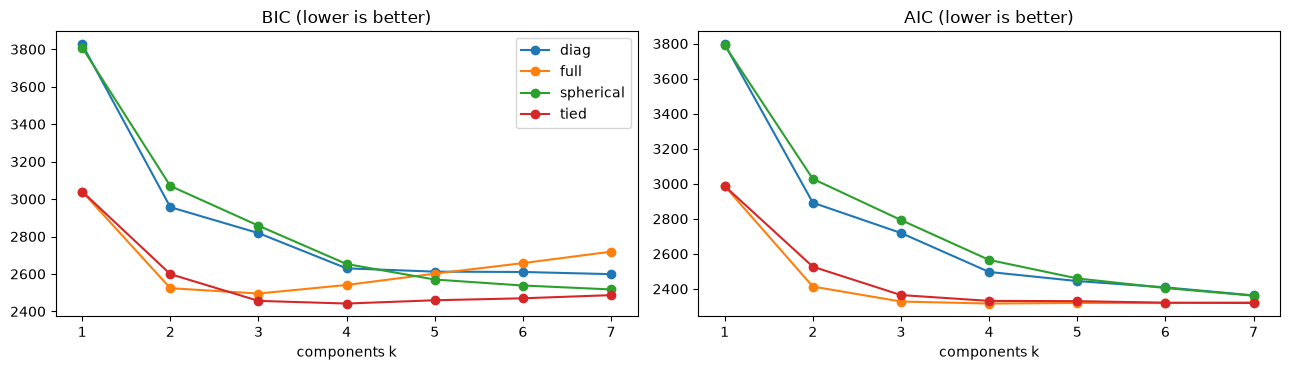

Components of the best-BIC model vs species and sex (never used for fitting):
species Adelie      Chinstrap      Gentoo     
sex     Female Male    Female Male Female Male
row_0                                         
0           56   33         5    0      0    0
1            0    0         0    0     58   61
2           17   40         0    0      0    0
3            0    0        29   34      0    0
  component 0: 94 penguins, 95% Adelie, 35% male
  component 1: 119 penguins, 100% Gentoo, 51% male
  component 2: 57 penguins, 100% Adelie, 70% male
  component 3: 63 penguins, 100% Chinstrap, 54% male


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for cov_type, part in bic_table.groupby("covariance"):
    axes[0].plot(part["k"], part["BIC"], "o-", label=cov_type)
    axes[1].plot(part["k"], part["AIC"], "o-", label=cov_type)
axes[0].set(title="BIC (lower is better)", xlabel="components k")
axes[1].set(title="AIC (lower is better)", xlabel="components k")
axes[0].legend()
plt.tight_layout()
plt.show()

best_labels = chosen.predict(X_pen4)
component_story = pd.crosstab(best_labels, [penguins["species"], penguins["sex"]])
print(f"Components of the best-BIC model vs species and sex (never used for fitting):\n{component_story}")
species_share = pd.crosstab(best_labels, penguins["species"], normalize="index")
male_share = pd.crosstab(best_labels, penguins["sex"], normalize="index")["Male"]
for comp in species_share.index:
    print(f"  component {comp}: {np.sum(best_labels == comp)} penguins, {species_share.loc[comp].max():.0%} "
          f"{species_share.loc[comp].idxmax()}, {male_share.loc[comp]:.0%} male")

**Lesson:** BIC chooses the best **density model** of the data, which is not necessarily the grouping you care about. If BIC picks more components than there are species, look at the crosstab: an extra component can capture a real sub-structure (such as a difference between males and females) or just a non-Gaussian shape. Use BIC to shortlist, then decide with the question.

### ✍️ Your Turn

How many free parameters does a **full**-covariance GMM with $k = 3$ components in $d = 4$ dimensions have? Count means, covariances and weights (don't call `n_gmm_parameters`).

In [23]:
n_params_full = None  # TODO
check("n_params_full", n_params_full, 44, hint="means 3·4, covariances 3·(4·5/2), weights 3−1.")

⏳ n_params_full: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
k, d = 3, 4
n_params_full = k * d + k * d * (d + 1) // 2 + (k - 1)     # 12 + 30 + 2
check("n_params_full", n_params_full, 44)
check("matches scikit-learn", bic_models[("full", 3)]._n_parameters(), 44)
```

A covariance matrix is symmetric, so only $d(d+1)/2 = 10$ of its 16 entries are free. The weights have $k-1$ free values because they sum to 1.
</details>

> 💡 **Interview angle:** "How do you choose the number of components in a GMM?" — fit a grid of k and covariance types and pick the lowest BIC (or AIC if prediction matters more than parsimony); check stability across `n_init`, and whether the components make sense. Alternatively `BayesianGaussianMixture` with a Dirichlet prior switches off unneeded components.

## 9. GMM as a Density Model: Anomaly Scores 🟡

A fitted GMM gives $\log p(x)$ for any point: `score_samples(X)`. **Low density = unusual.** A simple anomaly detector:

1. Fit on "normal" training data.
2. Set a threshold at a low percentile (e.g. 1%) of the **training** log-densities.
3. Flag new points below the threshold.

We use time honestly: fit on pickups from **April 1–21** and score pickups from **April 22–30**. The number of components comes from BIC on the training weeks. Pickups aren't a few neat Gaussian blobs, so expect BIC to prefer many components. Here the GMM is a flexible **density estimator**, not a set of interpretable clusters.

(Notebook [15 · Anomaly Detection](15_Anomaly_Detection.ipynb) compares this with Isolation Forest, LOF and One-Class SVM.)

BIC by k: {5: 179441, 10: 176118, 20: 171281, 30: 168127, 40: 168083} → k = 40 (still improving at the largest k tried: the density is far from a few Gaussians)


threshold = 1st percentile of training log-density = -11.10
test weeks: 0.85% of pickups flagged (expected ≈ 1% if the pattern is unchanged)
median distance from Times Square: flagged 22.1 km vs normal 2.8 km
3 synthetic pickups sampled from the model (lat, lon): [[40.7675, -73.9711], [40.7769, -73.9585], [40.7556, -73.9844]]


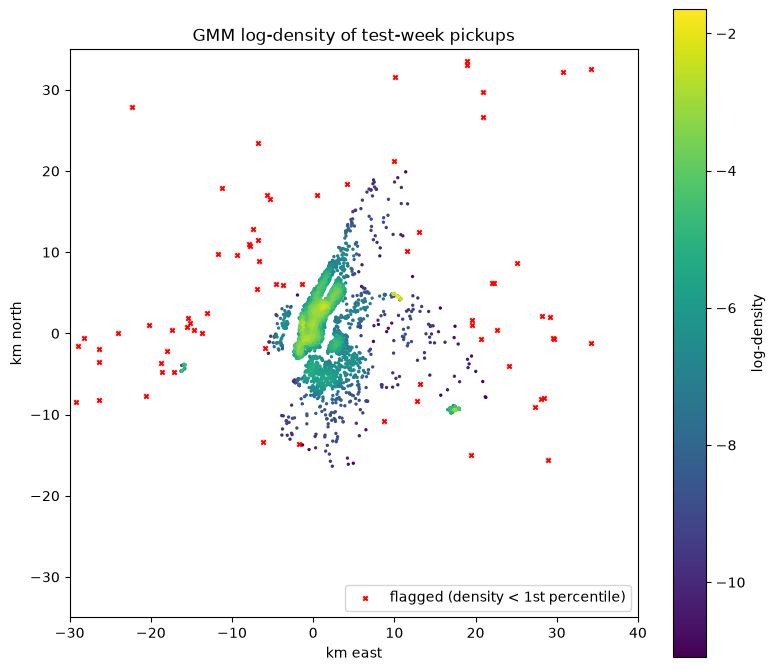

In [24]:
train_weeks = (uber["Date/Time"] < "2014-04-22").to_numpy()
train_pool, test_pool = np.flatnonzero(train_weeks), np.flatnonzero(~train_weeks)
X_week_train = uber_xy_all[rng.choice(train_pool, size=20_000, replace=False)]
X_week_test = uber_xy_all[rng.choice(test_pool, size=10_000, replace=False)]

bic_by_k = {}
for k in [5, 10, 20, 30, 40]:
    bic_by_k[k] = GaussianMixture(n_components=k, covariance_type="full", random_state=SEED).fit(X_week_train).bic(X_week_train)
k_density = min(bic_by_k, key=bic_by_k.get)
print("BIC by k:", {k: round(v) for k, v in bic_by_k.items()}, f"→ k = {k_density}"
      + (" (still improving at the largest k tried: the density is far from a few Gaussians)" if k_density == max(bic_by_k) else ""))

density_gmm = GaussianMixture(n_components=k_density, covariance_type="full", random_state=SEED).fit(X_week_train)
train_logd = density_gmm.score_samples(X_week_train)
threshold = np.quantile(train_logd, 0.01)
test_logd = density_gmm.score_samples(X_week_test)
flagged = test_logd < threshold
dist_times_sq = np.linalg.norm(X_week_test - LANDMARK_XY["Times Square"], axis=1)
print(f"threshold = 1st percentile of training log-density = {threshold:.2f}")
print(f"test weeks: {flagged.mean():.2%} of pickups flagged (expected ≈ 1% if the pattern is unchanged)")
print(f"median distance from Times Square: flagged {np.median(dist_times_sq[flagged]):.1f} km vs normal {np.median(dist_times_sq[~flagged]):.1f} km")

synthetic, synthetic_comp = density_gmm.sample(3)
print("3 synthetic pickups sampled from the model (lat, lon):", to_latlon(synthetic).round(4).tolist())

fig, ax = plt.subplots(figsize=(8, 7))
sc = ax.scatter(*X_week_test[~flagged].T, c=test_logd[~flagged], cmap="viridis", s=2)
ax.scatter(*X_week_test[flagged].T, c="red", s=10, marker="x", label="flagged (density < 1st percentile)")
fig.colorbar(sc, ax=ax, label="log-density")
ax.set(title="GMM log-density of test-week pickups", xlabel="km east", ylabel="km north", xlim=(-30, 40), ylim=(-35, 35), aspect="equal")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

> 💡 **Interview angle:** "How can clustering models detect anomalies?" — GMM: `score_samples` log-density with a threshold chosen on training data (a percentile or a validation set with known anomalies); DBSCAN/HDBSCAN: noise points; K-Means: distance to the nearest centroid. Point out that the threshold must be chosen without the test data, and that density models degrade in high dimensions.

## 10. Comparing Every Clustering Algorithm 🔴

All nine algorithms from notebooks 12–13 on the **same real datasets**, with **label-free parameter rules**, so nothing is tuned on the answers:

- k-based methods (K-Means, MiniBatchKMeans, BisectingKMeans, Ward, Average linkage, GMM) get $k$ = the number of true classes (the pickups get $k = 10$);
- DBSCAN and OPTICS use `min_samples = min(2·d, 20)`, and DBSCAN's `eps` is the k-distance knee;
- HDBSCAN uses `min_cluster_size = max(5, n/50)`.

For labelled datasets we report ARI; for the unlabelled pickups the silhouette of non-noise points. Every model runs on the same data (5,000 pickups to keep the $O(n^2)$ methods affordable).

In [25]:
wine = load_wine()
digits = load_digits()
compare_sets = {
    "penguins (333×4)": (X_pen4, species, 3),
    "wine (178×13)": (StandardScaler().fit_transform(wine.data), wine.target, 3),
    "digits (1797×64)": (digits.data, digits.target, 10),
    "NYC pickups (5000×2)": (X_uber[:5000], None, 10),
}


def make_algorithms(X, k):
    ms = min(2 * X.shape[1], 20)
    eps = knee_value(k_distances(X, ms))
    return {
        "K-Means": KMeans(n_clusters=k, n_init=10, random_state=SEED),
        "MiniBatchKMeans": MiniBatchKMeans(n_clusters=k, n_init=10, random_state=SEED),
        "BisectingKMeans": BisectingKMeans(n_clusters=k, n_init=5, random_state=SEED),
        "Ward": AgglomerativeClustering(n_clusters=k, linkage="ward"),
        "Average linkage": AgglomerativeClustering(n_clusters=k, linkage="average"),
        "DBSCAN": DBSCAN(eps=eps, min_samples=ms),
        "OPTICS": OPTICS(min_samples=ms),
        "HDBSCAN": HDBSCAN(min_cluster_size=max(5, len(X) // 50), copy=True),
        "GMM (full)": GaussianMixture(n_components=k, covariance_type="full", n_init=3, random_state=SEED),
    }


cmp_rows = []
for ds_name, (X_ds, y_ds, k) in compare_sets.items():
    for algo, model in make_algorithms(X_ds, k).items():
        start = time.perf_counter()
        with np.errstate(divide="ignore", invalid="ignore"):   # OPTICS' xi extraction divides by zero reachability on duplicate points
            lab = model.fit_predict(X_ds)
        seconds = time.perf_counter() - start
        clustered = lab >= 0
        n_found = len(np.unique(lab[clustered]))
        row = {"dataset": ds_name, "algorithm": algo, "clusters found": n_found, "noise %": 100 * (1 - clustered.mean()), "seconds": seconds}
        if y_ds is not None:
            row["score"] = adjusted_rand_score(y_ds, lab)                     # noise counts as its own group: an honest penalty
        elif n_found >= 2:
            row["score"] = silhouette_score(X_ds[clustered], lab[clustered], sample_size=min(2000, clustered.sum()), random_state=SEED)
        else:
            row["score"] = np.nan
        cmp_rows.append(row)
cmp = pd.DataFrame(cmp_rows)
for metric in ["score", "noise %", "clusters found", "seconds"]:
    title = {"score": "ARI vs true labels (pickups: silhouette of non-noise points)"}.get(metric, metric)
    print(f"\n{title}:\n", cmp.pivot(index="algorithm", columns="dataset", values=metric).round(3))


ARI vs true labels (pickups: silhouette of non-noise points):
 dataset          NYC pickups (5000×2)  digits (1797×64)  penguins (333×4)  wine (178×13)
algorithm                                                                               
Average linkage                 0.746             0.514             0.943         -0.005
BisectingKMeans                 0.364             0.627             0.799          0.706
DBSCAN                          0.141             0.000             0.636         -0.007
GMM (full)                      0.267             0.702             0.959          0.880
HDBSCAN                         0.777             0.118             0.646          0.346
K-Means                         0.395             0.667             0.799          0.897
MiniBatchKMeans                 0.332             0.723             0.897          0.897
OPTICS                          0.562             0.001             0.070          0.126
Ward                            0.423         

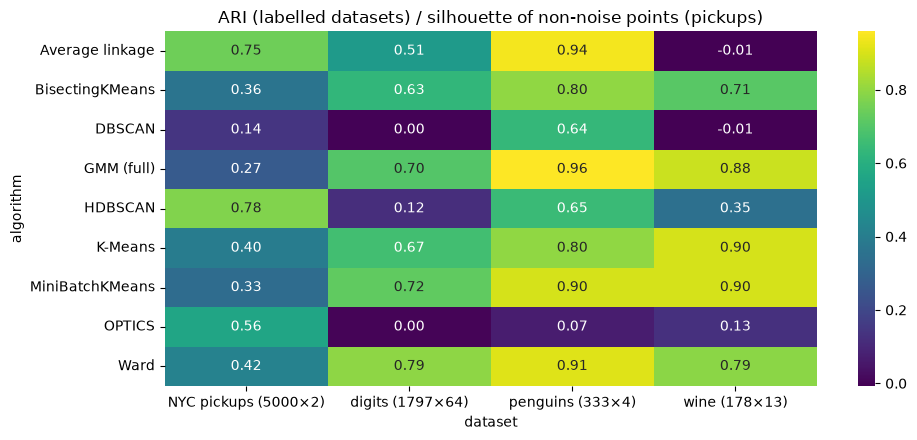

penguins (333×4)     best ARI: GMM (full) (0.959); best density method: HDBSCAN (0.646)
wine (178×13)        best ARI: K-Means (0.897); best density method: HDBSCAN (0.346)
digits (1797×64)     best ARI: Ward (0.794); best density method: HDBSCAN (0.118)
Density methods label 42% of rows as noise on the labelled (4–64-D) tables vs 14% on the 2-D pickups.
Slowest in total: OPTICS (1.8s over the four datasets).


In [26]:
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.heatmap(cmp.pivot(index="algorithm", columns="dataset", values="score"), annot=True, fmt=".2f", cmap="viridis", ax=ax)
ax.set_title("ARI (labelled datasets) / silhouette of non-noise points (pickups)")
plt.tight_layout()
plt.show()

density_algos = ["DBSCAN", "OPTICS", "HDBSCAN"]
labelled = [d for d, (_, y, _) in compare_sets.items() if y is not None]
for ds in labelled:
    part = cmp[cmp["dataset"] == ds].set_index("algorithm")
    print(f"{ds:20s} best ARI: {part['score'].idxmax()} ({part['score'].max():.3f}); best density method: "
          f"{part.loc[density_algos, 'score'].idxmax()} ({part.loc[density_algos, 'score'].max():.3f})")
lab_noise = cmp[cmp["dataset"].isin(labelled) & cmp["algorithm"].isin(density_algos)]["noise %"].mean()
geo_noise = cmp[(cmp["dataset"] == "NYC pickups (5000×2)") & cmp["algorithm"].isin(density_algos)]["noise %"].mean()
slowest = cmp.groupby("algorithm")["seconds"].sum().idxmax()
print(f"Density methods label {lab_noise:.0f}% of rows as noise on the labelled (4–64-D) tables vs {geo_noise:.0f}% on the 2-D pickups.")
print(f"Slowest in total: {slowest} ({cmp.groupby('algorithm')['seconds'].sum().max():.1f}s over the four datasets).")

**Reading the comparison.** On the labelled tables the classes overlap and have no low-density gaps between them, so density-based methods call many points noise or merge classes. Centroid and mixture models, which assume blob-like groups, do better there. On the 2-D pickups the density methods leave far less noise, but the silhouette column can't tell you whether hotspots are *useful*: it rewards a few well-separated round groups. That's why the mini project judges hotspots with operational metrics instead. Keep this table in mind together with the qualitative summary below:

| Algorithm | Main parameters | Cluster shapes | Noise | Varying density | Scales to | New points | Soft |
|---|---|---|---|---|---|---|---|
| K-Means | k | round, similar size | no | no | millions (MiniBatch: more) | `predict` | no |
| BisectingKMeans | k | round; hierarchical splits | no | no | millions | `predict` | no |
| Ward / complete / average | k or distance threshold, linkage | Ward round; single/average more flexible | no | partly (single) | ~10–20k rows ($O(n^2)$ memory) | no | no |
| DBSCAN | eps, min_samples | **any** | **yes** | **no** | ~millions in low-d with an index | nearest-core rule | no |
| OPTICS | min_samples, xi / eps cut | any | yes | **yes** | slower than DBSCAN | no | no |
| HDBSCAN | min_cluster_size (min_samples) | any | yes | **yes** | ~millions in low-d | no (`hdbscan` pkg: approximate) | membership strength |
| GMM | k, covariance_type | **ellipses** | via low density | partly (different Σ) | ~100k+ rows, moderate d | `predict` | **yes** |

> 💡 **Interview angle:** "Which clustering algorithm would you use?" — ask about the data first: size, dimensionality, expected shapes, noise, whether k is known, whether new points need labels and whether probabilities matter. Then name a first choice and a fallback (e.g. "coordinates with noise → HDBSCAN, fallback DBSCAN with a k-distance eps; high-dimensional embeddings → reduce with UMAP/PCA first").

## 🔧 Build It From Scratch

### 1) DBSCAN with brute-force neighbourhoods

We compute the full distance matrix (fine for 2,000 points), find each point's `eps`-neighbourhood, mark core points, and grow clusters with a stack, visiting points **in index order**, the same order scikit-learn uses.

**Border-point ambiguity.** A border point can lie within `eps` of core points from **two different clusters**. DBSCAN gives it to whichever cluster reaches it **first**, so its label depends on the processing order. Core points and noise are always the same. So we assert: identical core points, identical noise, core labels identical up to renaming (ARI = 1), and every border point labelled with *one of* the clusters of its core neighbours. Then we count how many border points are genuinely ambiguous.

In [27]:
def dbscan_scratch(X, eps, min_samples):
    sq = ((X[:, None, :] - X[None, :, :]) ** 2).sum(axis=2)
    neighbours = [np.flatnonzero(row <= eps**2) for row in sq]                  # includes the point itself
    is_core = np.array([len(nb) >= min_samples for nb in neighbours])
    labels = np.full(len(X), -1)
    cluster = 0
    for i in range(len(X)):
        if labels[i] != -1 or not is_core[i]:
            continue
        labels[i] = cluster
        stack = [i]
        while stack:                                                           # expand through core points
            p = stack.pop()
            for q in neighbours[p]:
                if labels[q] == -1:
                    labels[q] = cluster
                    if is_core[q]:
                        stack.append(q)
        cluster += 1
    return labels, is_core, neighbours


X_scratch = X_uber[:2000]
ambiguity = {}
for eps, ms in [(0.3, 10), (0.6, 4), (1.0, 5)]:
    ours, is_core, neighbours = dbscan_scratch(X_scratch, eps, ms)
    sk = DBSCAN(eps=eps, min_samples=ms).fit(X_scratch)
    sk_core = np.zeros(len(X_scratch), dtype=bool)
    sk_core[sk.core_sample_indices_] = True
    assert np.array_equal(is_core, sk_core), "core points differ"
    assert np.array_equal(ours == -1, sk.labels_ == -1), "noise differs"
    assert adjusted_rand_score(ours[is_core], sk.labels_[is_core]) == 1.0, "core clusters differ"
    border = np.flatnonzero(~is_core & (ours != -1))
    candidate_sets = [{ours[q] for q in neighbours[b] if is_core[q]} for b in border]
    assert all(ours[b] in cands for b, cands in zip(border, candidate_sets))
    ambiguity[(eps, ms)] = [b for b, cands in zip(border, candidate_sets) if len(cands) > 1]
    print(f"✅ eps={eps}, min_samples={ms}: {ours.max() + 1} clusters, {is_core.sum()} core, {len(border)} border "
          f"({len(ambiguity[(eps, ms)])} ambiguous), {np.sum(ours == -1)} noise | identical to scikit-learn label-for-label: "
          f"{np.array_equal(ours, sk.labels_)}")

✅ eps=0.3, min_samples=10: 8 clusters, 1408 core, 152 border (2 ambiguous), 440 noise | identical to scikit-learn label-for-label: True
✅ eps=0.6, min_samples=4: 15 clusters, 1876 core, 18 border (0 ambiguous), 106 noise | identical to scikit-learn label-for-label: True


✅ eps=1.0, min_samples=5: 10 clusters, 1900 core, 19 border (1 ambiguous), 81 noise | identical to scikit-learn label-for-label: True


In [28]:
eps_amb, ms_amb = max(ambiguity, key=lambda key: len(ambiguity[key]))
reference = DBSCAN(eps=eps_amb, min_samples=ms_amb).fit(X_scratch)
core_ref = np.zeros(len(X_scratch), dtype=bool)
core_ref[reference.core_sample_indices_] = True
changed_any = set()
for s in range(20):
    perm = np.random.default_rng(s).permutation(len(X_scratch))
    shuffled = np.empty(len(X_scratch), dtype=int)
    shuffled[perm] = DBSCAN(eps=eps_amb, min_samples=ms_amb).fit_predict(X_scratch[perm])
    mapping = pd.crosstab(shuffled[core_ref], reference.labels_[core_ref]).idxmax(axis=1)   # rename clusters via their core points
    renamed = np.array([mapping[l] if l != -1 else -1 for l in shuffled])
    assert np.array_equal(renamed[core_ref], reference.labels_[core_ref]), "core points changed cluster"
    assert np.array_equal(shuffled == -1, reference.labels_ == -1), "noise changed"
    changed_any |= set(np.flatnonzero(renamed != reference.labels_).tolist())
n_amb = len(ambiguity[(eps_amb, ms_amb)])
assert changed_any <= set(ambiguity[(eps_amb, ms_amb)]), "a non-ambiguous point changed cluster"
print(f"20 shuffled row orders of the real pickups (eps={eps_amb}, min_samples={ms_amb}): core points and noise never changed; "
      + (f"{len(changed_any)} point(s) switched cluster, all of them among the {n_amb} ambiguous border points."
         if changed_any else f"none of the {n_amb} ambiguous border points switched — the same neighbouring cluster reached them first every time."))

# A tiny controlled example (1-D, made up on purpose) where the order provably matters:
# two dense groups with one border point at 0.6 that is within eps of a core point on each side.
toy = np.array([[0.0], [0.1], [0.2], [0.3], [0.6], [0.9], [1.0], [1.1], [1.2]])
forward = DBSCAN(eps=0.31, min_samples=4).fit_predict(toy)
backward = DBSCAN(eps=0.31, min_samples=4).fit_predict(toy[::-1])[::-1]       # same points, rows reversed
assert forward[4] == forward[0] and backward[4] == backward[-1]
print(f"toy example: the border point 0.6 joins the LEFT group in the original row order and the RIGHT group when the rows are reversed "
      f"(labels {forward.tolist()} vs {backward.tolist()}) — both answers are valid DBSCAN results.")

20 shuffled row orders of the real pickups (eps=0.3, min_samples=10): core points and noise never changed; none of the 2 ambiguous border points switched — the same neighbouring cluster reached them first every time.
toy example: the border point 0.6 joins the LEFT group in the original row order and the RIGHT group when the rows are reversed (labels [0, 0, 0, 0, 0, 1, 1, 1, 1] vs [1, 1, 1, 1, 0, 0, 0, 0, 0]) — both answers are valid DBSCAN results.


### 2) EM for a Gaussian mixture (NumPy only)

We write the log-density of a multivariate normal with a Cholesky factor (stable, no explicit inverse), do the E-step in log space with `logaddexp` (no underflow), and the M-step with weighted averages, adding `reg_covar` like scikit-learn. Starting from **the same initial weights, means and covariances**, our log-likelihood must match `GaussianMixture`.

In [29]:
def log_gaussian(X, mean, cov):
    """log N(x | mean, cov) for every row of X."""
    d = X.shape[1]
    L = np.linalg.cholesky(cov)
    z = np.linalg.solve(L, (X - mean).T)                   # whitened residuals, shape (d, n)
    return -0.5 * (d * np.log(2 * np.pi) + 2 * np.log(np.diag(L)).sum() + (z**2).sum(axis=0))


def em_gmm(X, weights, means, covs, n_iter, reg_covar=1e-6):
    n, d = X.shape
    history = []
    for _ in range(n_iter):
        log_p = np.column_stack([np.log(weights[k]) + log_gaussian(X, means[k], covs[k]) for k in range(len(weights))])
        log_norm = np.logaddexp.reduce(log_p, axis=1)                        # E-step, in log space
        history.append(log_norm.mean())
        resp = np.exp(log_p - log_norm[:, None])
        nk = resp.sum(axis=0) + 10 * np.finfo(float).eps                   # M-step
        weights = nk / n
        means = (resp.T @ X) / nk[:, None]
        covs = np.array([((resp[:, k, None] * (X - means[k])).T @ (X - means[k])) / nk[k] + reg_covar * np.eye(d)
                         for k in range(len(nk))])
    return weights, means, covs, np.array(history)


def mean_log_likelihood(X, weights, means, covs):
    return np.logaddexp.reduce(np.column_stack([np.log(w) + log_gaussian(X, m, c) for w, m, c in zip(weights, means, covs)]), axis=1).mean()


start_rows = np.random.default_rng(3).choice(len(X_pen4), 3, replace=False)
w0, m0, c0 = np.full(3, 1 / 3), X_pen4[start_rows], np.repeat(np.cov(X_pen4.T)[None], 3, axis=0)
sk_gmm = GaussianMixture(n_components=3, covariance_type="full", weights_init=w0, means_init=m0,
                         precisions_init=np.linalg.inv(c0), tol=1e-8, max_iter=1000).fit(X_pen4)
w_ours, m_ours, c_ours, hist = em_gmm(X_pen4, w0, m0, c0, n_iter=sk_gmm.n_iter_)
ours_ll = mean_log_likelihood(X_pen4, w_ours, m_ours, c_ours)
resp_ours = np.column_stack([np.log(w) + log_gaussian(X_pen4, m, c) for w, m, c in zip(w_ours, m_ours, c_ours)]).argmax(axis=1)
assert np.all(np.diff(hist) >= -1e-10), "our log-likelihood decreased"
assert abs(ours_ll - sk_gmm.score(X_pen4)) < 1e-6, "log-likelihood differs from scikit-learn"
assert adjusted_rand_score(resp_ours, sk_gmm.predict(X_pen4)) == 1.0
print(f"✅ after {sk_gmm.n_iter_} EM iterations: our mean log-likelihood {ours_ll:.8f} vs scikit-learn {sk_gmm.score(X_pen4):.8f} "
      f"(difference {abs(ours_ll - sk_gmm.score(X_pen4)):.1e}); identical hard labels; likelihood never decreased")

✅ after 50 EM iterations: our mean log-likelihood -3.36285426 vs scikit-learn -3.36285426 (difference 0.0e+00); identical hard labels; likelihood never decreased


## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Running DBSCAN on raw latitude/longitude degrees

One `eps` in degrees means different real distances east–west and north–south (a degree of longitude shrinks with $\cos(\text{latitude})$), and at large scales the Earth is not flat. Use kilometres (a projection) or `metric="haversine"` on **radians** with `eps = km / 6371`.

In [30]:
latlon = uber.loc[sample_idx, ["Lat", "Lon"]].to_numpy()
eps_km = 0.25
bad_deg = DBSCAN(eps=eps_km / 110.57, min_samples=MIN_SAMPLES).fit_predict(latlon)          # 0.25 km converted with the latitude rule only
good_hav = DBSCAN(eps=eps_km / 6371.0088, min_samples=MIN_SAMPLES, metric="haversine",
                  algorithm="ball_tree").fit_predict(np.radians(latlon))
good_km = DBSCAN(eps=eps_km, min_samples=MIN_SAMPLES).fit_predict(X_uber)
print(f"east–west reach of eps in degrees: {eps_km / 110.57 * 111.32 * np.cos(np.radians(LAT0)):.3f} km vs north–south {eps_km:.3f} km")
print(f"❌ degrees:   {bad_deg.max() + 1} clusters, {np.mean(bad_deg == -1):.1%} noise, ARI vs correct {adjusted_rand_score(good_hav, bad_deg):.3f}")
print(f"✅ haversine: {good_hav.max() + 1} clusters, {np.mean(good_hav == -1):.1%} noise | km projection agrees: ARI {adjusted_rand_score(good_hav, good_km):.3f}")

east–west reach of eps in degrees: 0.191 km vs north–south 0.250 km
❌ degrees:   21 clusters, 13.2% noise, ARI vs correct 0.983
✅ haversine: 24 clusters, 11.3% noise | km projection agrees: ARI 1.000


### ❌ Pitfall 2 — Expecting `DBSCAN`/`HDBSCAN` to label new points with `predict`

In [31]:
for model in (db_model, hdb_leaf):
    try:
        model.predict(X_week_test[:5])
    except AttributeError as err:
        print(f"❌ AttributeError: {err}")
print(f"✅ nearest-core-point rule (Section 5): {dbscan_assign(db_model, X_uber, X_week_test[:5])} | "
      f"or a model that has predict, e.g. GMM: {density_gmm.predict(X_week_test[:5])}")

❌ AttributeError: 'DBSCAN' object has no attribute 'predict'
❌ AttributeError: 'HDBSCAN' object has no attribute 'predict'
✅ nearest-core-point rule (Section 5): [6 0 0 0 0] | or a model that has predict, e.g. GMM: [ 3  1  2 28 12]


### ❌ Pitfall 3 — Scoring noise as if it were a cluster

In [32]:
with_noise_label = silhouette_score(X_uber, db_city, sample_size=5000, random_state=SEED)
mask = db_city >= 0
without_noise = silhouette_score(X_uber[mask], db_city[mask], sample_size=5000, random_state=SEED)
print(f"❌ silhouette treating label -1 as a cluster: {with_noise_label:.3f} (noise is scattered everywhere, not a cluster)")
print(f"✅ silhouette of clustered points: {without_noise:.3f}, reported together with the noise share {1 - mask.mean():.1%} "
      "(still low: one giant Manhattan cluster next to small ones is not the round-cluster shape silhouette rewards)")

❌ silhouette treating label -1 as a cluster: -0.083 (noise is scattered everywhere, not a cluster)
✅ silhouette of clustered points: 0.009, reported together with the noise share 11.3% (still low: one giant Manhattan cluster next to small ones is not the round-cluster shape silhouette rewards)


### ❌ Pitfall 4 — Trusting a single EM run

In [33]:
single_runs = [GaussianMixture(3, init_params="random_from_data", n_init=1, random_state=s).fit(X_pen4) for s in range(10)]
multi_runs = [GaussianMixture(3, init_params="random_from_data", n_init=10, random_state=s).fit(X_pen4) for s in range(5)]
ll_single = [g.score(X_pen4) for g in single_runs]
ari_single = [adjusted_rand_score(species, g.predict(X_pen4)) for g in single_runs]
ll_multi = [g.score(X_pen4) for g in multi_runs]
ari_multi = [adjusted_rand_score(species, g.predict(X_pen4)) for g in multi_runs]
print(f"❌ n_init=1 (10 seeds):  log-likelihood {min(ll_single):.3f} … {max(ll_single):.3f} | ARI {min(ari_single):.2f} … {max(ari_single):.2f}")
print(f"✅ n_init=10 (5 seeds):  log-likelihood {min(ll_multi):.3f} … {max(ll_multi):.3f} | ARI {min(ari_multi):.2f} … {max(ari_multi):.2f}")

❌ n_init=1 (10 seeds):  log-likelihood -3.822 … -3.363 | ARI 0.51 … 0.96
✅ n_init=10 (5 seeds):  log-likelihood -3.363 … -3.363 | ARI 0.95 … 0.96


### ❌ Pitfall 5 — Collapsing covariances (constant features, too many dimensions)

Several digit pixels are always 0, so a full covariance matrix is singular. Without regularization the fit fails.

In [34]:
try:
    GaussianMixture(n_components=10, covariance_type="full", reg_covar=0.0, random_state=SEED).fit(digits.data)
    print("❌ fit succeeded without regularization this time — but covariance matrices with zero variance are numerically fragile")
except ValueError as err:
    print(f"❌ ValueError: {str(err)[:170]}...")
safe = GaussianMixture(n_components=10, covariance_type="diag", random_state=SEED).fit(digits.data)
print(f"✅ covariance_type='diag' with the default reg_covar=1e-6: fitted in {safe.n_iter_} iterations, "
      f"ARI vs digit {adjusted_rand_score(digits.target, safe.predict(digits.data)):.3f} "
      "(or reduce dimensions with PCA first — next notebook)")

❌ ValueError: Fitting the mixture model failed because some components have ill-defined empirical covariance (for instance caused by singleton or collapsed samples). Try to decrease th...
✅ covariance_type='diag' with the default reg_covar=1e-6: fitted in 22 iterations, ARI vs digit 0.516 (or reduce dimensions with PCA first — next notebook)


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Count the core points
For the 1-D points below, with `eps=0.3` and `min_samples=3` (a point counts itself), how many **core** points are there?

In [35]:
pts_ex1 = np.array([[0.0], [0.2], [0.4], [3.0], [3.1], [9.0]])
n_core_ex1 = None  # TODO (by hand or with DBSCAN(...).fit(...).core_sample_indices_)
check("n_core_ex1", n_core_ex1, 1, hint="Only one point has 3 points (itself included) within 0.3.")

⏳ n_core_ex1: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
pts_ex1 = np.array([[0.0], [0.2], [0.4], [3.0], [3.1], [9.0]])
n_core_ex1 = len(DBSCAN(eps=0.3, min_samples=3).fit(pts_ex1).core_sample_indices_)
check("n_core_ex1", n_core_ex1, 1)
```
Only 0.2 has {0, 0.2, 0.4} within 0.3. The pair {3.0, 3.1} has just 2 points each, so it is noise, not a cluster.
</details>

### 🟢 Exercise 2 — BIC and AIC by hand
A model has total log-likelihood $\log L = -500$, $p = 20$ parameters and was fitted on $n = 1000$ rows. Compute BIC and AIC.

In [36]:
bic_aic_ex2 = None  # TODO: {"bic": ..., "aic": ...}
check("bic_aic_ex2", bic_aic_ex2, {"bic": 1138.155106, "aic": 1040.0}, hint="BIC = -2·logL + p·ln(n); AIC = -2·logL + 2p.")

⏳ bic_aic_ex2: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
log_L, p_ex, n_ex = -500.0, 20, 1000
bic_aic_ex2 = {"bic": -2 * log_L + p_ex * np.log(n_ex), "aic": -2 * log_L + 2 * p_ex}
check("bic_aic_ex2", bic_aic_ex2, {"bic": 1138.155106, "aic": 1040.0})
```
With $n = 1000$ each parameter costs $\ln 1000 \approx 6.9$ in BIC but only 2 in AIC.
</details>

### 🟢 Exercise 3 — Parameters of a diagonal GMM
How many free parameters does a `covariance_type="diag"` GMM with $k = 5$ components in $d = 3$ dimensions have?

In [37]:
n_params_diag = None  # TODO
check("n_params_diag", n_params_diag, 34, hint="means k·d + variances k·d + weights k−1.")

⏳ n_params_diag: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
k, d = 5, 3
n_params_diag = k * d + k * d + (k - 1)          # 15 + 15 + 4
check("n_params_diag", n_params_diag, 34)
```
</details>

### 🟡 Exercise 4 — Vectorized E-step
For a 1-D two-component mixture with weights `[0.3, 0.7]`, means `[0, 3]` and standard deviations `[1, 1]`, compute the **responsibility matrix** (rows = points, columns = components) for `x = [-1, 0, 3]`, with no loops.

In [38]:
x_e = np.array([-1.0, 0.0, 3.0])
pi_e, mu_e, sd_e = np.array([0.3, 0.7]), np.array([0.0, 3.0]), np.array([1.0, 1.0])
resp_e = None  # TODO: shape (3, 2), rows sum to 1
check("resp_e", resp_e, [[0.998711, 0.001289], [0.974734, 0.025266], [0.004738, 0.995262]],
      hint="Broadcast x_e[:, None] against the (2,) parameter arrays inside norm.pdf, multiply by pi_e, normalize rows.")

⏳ resp_e: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
x_e = np.array([-1.0, 0.0, 3.0])
pi_e, mu_e, sd_e = np.array([0.3, 0.7]), np.array([0.0, 3.0]), np.array([1.0, 1.0])
weighted = pi_e * norm.pdf(x_e[:, None], mu_e, sd_e)          # (3, 2)
resp_e = weighted / weighted.sum(axis=1, keepdims=True)
check("resp_e", resp_e, [[0.998711, 0.001289], [0.974734, 0.025266], [0.004738, 0.995262]])
```
Even though component 2 has the larger weight (0.7), the point at 0 is 97% component 1: the likelihood term dominates the prior. In real code use log-densities and `logaddexp` to avoid underflow.
</details>

### 🟡 Exercise 5 — Find the knee of a k-distance curve
Implement `knee_index(values)` for a sorted, increasing curve: normalize both axes to [0, 1] and return the index where the curve lies **farthest below** the straight line from the first to the last point.

In [39]:
def knee_index(values):
    # TODO: return an int index
    return None


check("knee_index", knee_index(np.array([0.1, 0.1, 0.12, 0.13, 0.15, 0.2, 1.0, 3.0])), 5,
      hint="x = np.linspace(0, 1, n); y = (v - v[0]) / (v[-1] - v[0]); argmax of x - y.")

⏳ knee_index: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def knee_index(values):
    values = np.asarray(values, dtype=float)
    x = np.linspace(0, 1, len(values))
    y = (values - values[0]) / (values[-1] - values[0])
    return int(np.argmax(x - y))


check("knee_index", knee_index(np.array([0.1, 0.1, 0.12, 0.13, 0.15, 0.2, 1.0, 3.0])), 5)
```
The value at index 5 (0.2) is the last "flat" point before the curve shoots up, a good `eps`.
</details>

### 🔴 Exercise 6 — One full EM iteration (interview classic)
Implement `em_step_1d(x, weights, means, variances)` for a 1-D Gaussian mixture. It returns `(new_weights, new_means, new_variances, mean_loglik)`, where `mean_loglik` is the mean log-likelihood **before** the update (computed in the E-step).

In [40]:
def em_step_1d(x, weights, means, variances):
    # TODO: E-step (responsibilities + mean log-likelihood), then M-step
    return None


result_ex6 = em_step_1d(np.array([0.0, 1.0, 2.0, 4.0, 8.0, 9.0]), np.array([0.5, 0.5]), np.array([1.0, 8.0]), np.array([4.0, 4.0]))
check("em_step_1d", None if result_ex6 is None else
      {"weights": result_ex6[0], "means": result_ex6[1], "variances": result_ex6[2], "mean_loglik": result_ex6[3]},
      {"weights": [0.6155589, 0.3844411], "means": [1.57498487, 7.88288251], "variances": [1.9628436, 2.71139581],
       "mean_loglik": -2.49421882},
      hint="norm.pdf(x[:, None], means, np.sqrt(variances)); the point at 4 is shared between both components.")

⏳ em_step_1d: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def em_step_1d(x, weights, means, variances):
    weighted = weights * norm.pdf(x[:, None], means, np.sqrt(variances))      # (n, k)
    mean_loglik = np.log(weighted.sum(axis=1)).mean()
    resp = weighted / weighted.sum(axis=1, keepdims=True)                     # E-step
    nk = resp.sum(axis=0)                                                     # M-step
    new_means = (resp * x[:, None]).sum(axis=0) / nk
    new_vars = (resp * (x[:, None] - new_means) ** 2).sum(axis=0) / nk
    return nk / len(x), new_means, new_vars, mean_loglik


result_ex6 = em_step_1d(np.array([0.0, 1.0, 2.0, 4.0, 8.0, 9.0]), np.array([0.5, 0.5]), np.array([1.0, 8.0]), np.array([4.0, 4.0]))
check("em_step_1d", {"weights": result_ex6[0], "means": result_ex6[1], "variances": result_ex6[2], "mean_loglik": result_ex6[3]},
      {"weights": [0.6155589, 0.3844411], "means": [1.57498487, 7.88288251], "variances": [1.9628436, 2.71139581], "mean_loglik": -2.49421882})
```
The point at 4 is 3 away from mean 1 but 4 away from mean 8, so it goes mostly, not fully, to component 1. That pulls component 1's mean up to 1.57 and gives it more than half the weight. Run a second step and check that `mean_loglik` goes up.
</details>

## 🚀 Mini Project: NYC Pickup Hotspots

**Business goal:** a ride-hailing operations team wants to know **where idle drivers should wait**. They need compact, busy **hotspots**, airports kept separate from the city, pickups outside any hotspot left alone rather than forced into one, and hotspots that are still there **next week**.

**Data:** the real Uber pickups of April 2014. To avoid leakage in time, every modelling choice uses **April 1–21**, and **April 22–30** only checks whether the hotspots persist.

**Candidates:** DBSCAN, HDBSCAN, K-Means and a Gaussian mixture.

### Step 1 — Fixed samples for the two periods

In [41]:
proj_train = uber_xy_all[rng.choice(train_pool, size=20_000, replace=False)]
proj_test = uber_xy_all[rng.choice(test_pool, size=20_000, replace=False)]      # same size, so density parameters mean the same thing
print(f"April 1–21: {len(train_pool):,} pickups (sampled {len(proj_train):,}) | April 22–30: {len(test_pool):,} pickups (sampled {len(proj_test):,})")
hours = uber["Date/Time"].dt.hour
print("busiest pickup hours:", hours.value_counts().head(3).to_dict())

April 1–21: 364,585 pickups (sampled 20,000) | April 22–30: 199,931 pickups (sampled 20,000)
busiest pickup hours: {17: 45475, 18: 43003, 16: 42003}


### Step 2 — Parameters, decided on the training weeks only

- **DBSCAN:** the team's own definition of a hotspot, *at least 20 sampled pickups within 250 m* → `eps=0.25`, `min_samples=20`. (Section 2 showed that `eps` at the k-distance knee merges almost the whole city into one cluster.)
- **HDBSCAN:** `min_cluster_size` = 1% of the sample (200 pickups), `min_samples=20`, `"leaf"` selection for fine-grained hotspots.
- **K-Means:** k from the best silhouette on the training sample.
- **GMM:** k from BIC on the training sample (a grid, like Section 9).

In [42]:
sil_by_k = {}
for k in [5, 10, 15, 20, 30]:
    lab = KMeans(n_clusters=k, n_init=5, random_state=SEED).fit_predict(proj_train)
    sil_by_k[k] = silhouette_score(proj_train, lab, sample_size=4000, random_state=SEED)
k_km = max(sil_by_k, key=sil_by_k.get)
bic_proj = {k: GaussianMixture(n_components=k, covariance_type="full", random_state=SEED).fit(proj_train).bic(proj_train)
            for k in [10, 20, 30, 40]}
k_gmm = min(bic_proj, key=bic_proj.get)
print("K-Means silhouette by k:", {k: round(v, 3) for k, v in sil_by_k.items()}, f"→ k = {k_km}")
print("GMM BIC by k:", {k: round(v) for k, v in bic_proj.items()}, f"→ k = {k_gmm}")


def make_hotspot_models():
    return {
        "DBSCAN": DBSCAN(eps=0.25, min_samples=20),
        "HDBSCAN": HDBSCAN(min_cluster_size=200, min_samples=20, cluster_selection_method="leaf", copy=True),
        f"K-Means (k={k_km})": KMeans(n_clusters=k_km, n_init=10, random_state=SEED),
        f"GMM (k={k_gmm})": GaussianMixture(n_components=k_gmm, covariance_type="full", random_state=SEED),
    }

K-Means silhouette by k: {5: 0.453, 10: 0.398, 15: 0.412, 20: 0.398, 30: 0.39} → k = 5
GMM BIC by k: {10: 174373, 20: 170148, 30: 169073, 40: 168845} → k = 40


### Step 3 — Fit on the training weeks and measure what operations cares about

- **hotspots** and **coverage** (share of pickups inside a hotspot);
- **largest hotspot %**: a giant blob is useless for positioning drivers;
- **radius**: the distance covering 90% of a hotspot's pickups from its centre (median and worst across hotspots);
- **airports separate** and **Midtown ≠ Wall Street**: does it resolve the places that matter?

In [43]:
def hotspot_metrics(X, labels):
    ids = np.unique(labels[labels >= 0])
    radii = np.array([np.quantile(np.linalg.norm(X[labels == c] - X[labels == c].mean(axis=0), axis=1), 0.9) for c in ids])
    sizes = np.array([np.sum(labels == c) for c in ids])
    marks = {m: label_near(labels, X, LANDMARK_XY[m], radius=1.0 if "Airport" in m else 0.4)
             for m in ["Times Square", "Wall Street", "JFK Airport", "LaGuardia Airport"]}
    airports_ok = (None not in (marks["JFK Airport"], marks["LaGuardia Airport"]) and marks["JFK Airport"] != marks["LaGuardia Airport"]
                   and not {marks["JFK Airport"], marks["LaGuardia Airport"]} & {marks["Times Square"], marks["Wall Street"]})
    return {"hotspots": len(ids), "coverage %": 100 * np.mean(labels >= 0), "largest hotspot %": 100 * sizes.max() / len(X),
            "median radius km": float(np.median(radii)), "worst radius km": float(radii.max()),
            "airports separate": bool(airports_ok),
            "Midtown ≠ Wall St": marks["Times Square"] is not None and marks["Times Square"] != marks["Wall Street"]}


def hotspot_centres(X, labels):
    ids = np.unique(labels[labels >= 0])
    return np.array([X[labels == c].mean(axis=0) for c in ids]), np.array([np.sum(labels == c) for c in ids])


proj_rows, proj_labels = [], {}
for name, model in make_hotspot_models().items():
    start = time.perf_counter()
    lab = model.fit_predict(proj_train)
    fit_s = time.perf_counter() - start
    proj_labels[name] = lab
    proj_rows.append({"method": name, **hotspot_metrics(proj_train, lab), "fit s": fit_s})
proj_table = pd.DataFrame(proj_rows).set_index("method")
print(proj_table.round(2).to_string())

               hotspots  coverage %  largest hotspot %  median radius km  worst radius km  airports separate  Midtown ≠ Wall St  fit s
method                                                                                                                                
DBSCAN               21       87.82              77.78              0.34             4.21               True              False   0.06
HDBSCAN              14       39.88               8.80              0.49             3.03               True               True   0.58
K-Means (k=5)         5      100.00              47.10              9.08            13.03               True               True   0.05
GMM (k=40)           40      100.00               9.63              1.48            45.27               True               True   0.39


### Step 4 — Do the hotspots persist next week?

We refit each method with **the same parameters** on the April 22–30 sample, match hotspot centres one-to-one (Hungarian algorithm), and count the share of training hotspots with a partner **within 500 m**.

In [44]:
persist = {}
for name, model in make_hotspot_models().items():
    test_lab = model.fit_predict(proj_test)
    c_train, _ = hotspot_centres(proj_train, proj_labels[name])
    c_test, _ = hotspot_centres(proj_test, test_lab)
    dist = np.linalg.norm(c_train[:, None] - c_test[None], axis=2)
    r_idx, c_idx = linear_sum_assignment(dist)
    persist[name] = np.sum(dist[r_idx, c_idx] <= 0.5) / len(c_train)
    print(f"{name:14s} {len(c_train)} training hotspots, {len(c_test)} test-week hotspots, "
          f"{persist[name]:.0%} re-found within 500 m | test-week coverage {100 * np.mean(test_lab >= 0):.0f}%")
proj_table["persist %"] = pd.Series(persist) * 100

DBSCAN         21 training hotspots, 17 test-week hotspots, 43% re-found within 500 m | test-week coverage 89%


HDBSCAN        14 training hotspots, 21 test-week hotspots, 93% re-found within 500 m | test-week coverage 40%
K-Means (k=5)  5 training hotspots, 5 test-week hotspots, 20% re-found within 500 m | test-week coverage 100%


GMM (k=40)     40 training hotspots, 40 test-week hotspots, 42% re-found within 500 m | test-week coverage 100%


### Step 5 — See them on the map

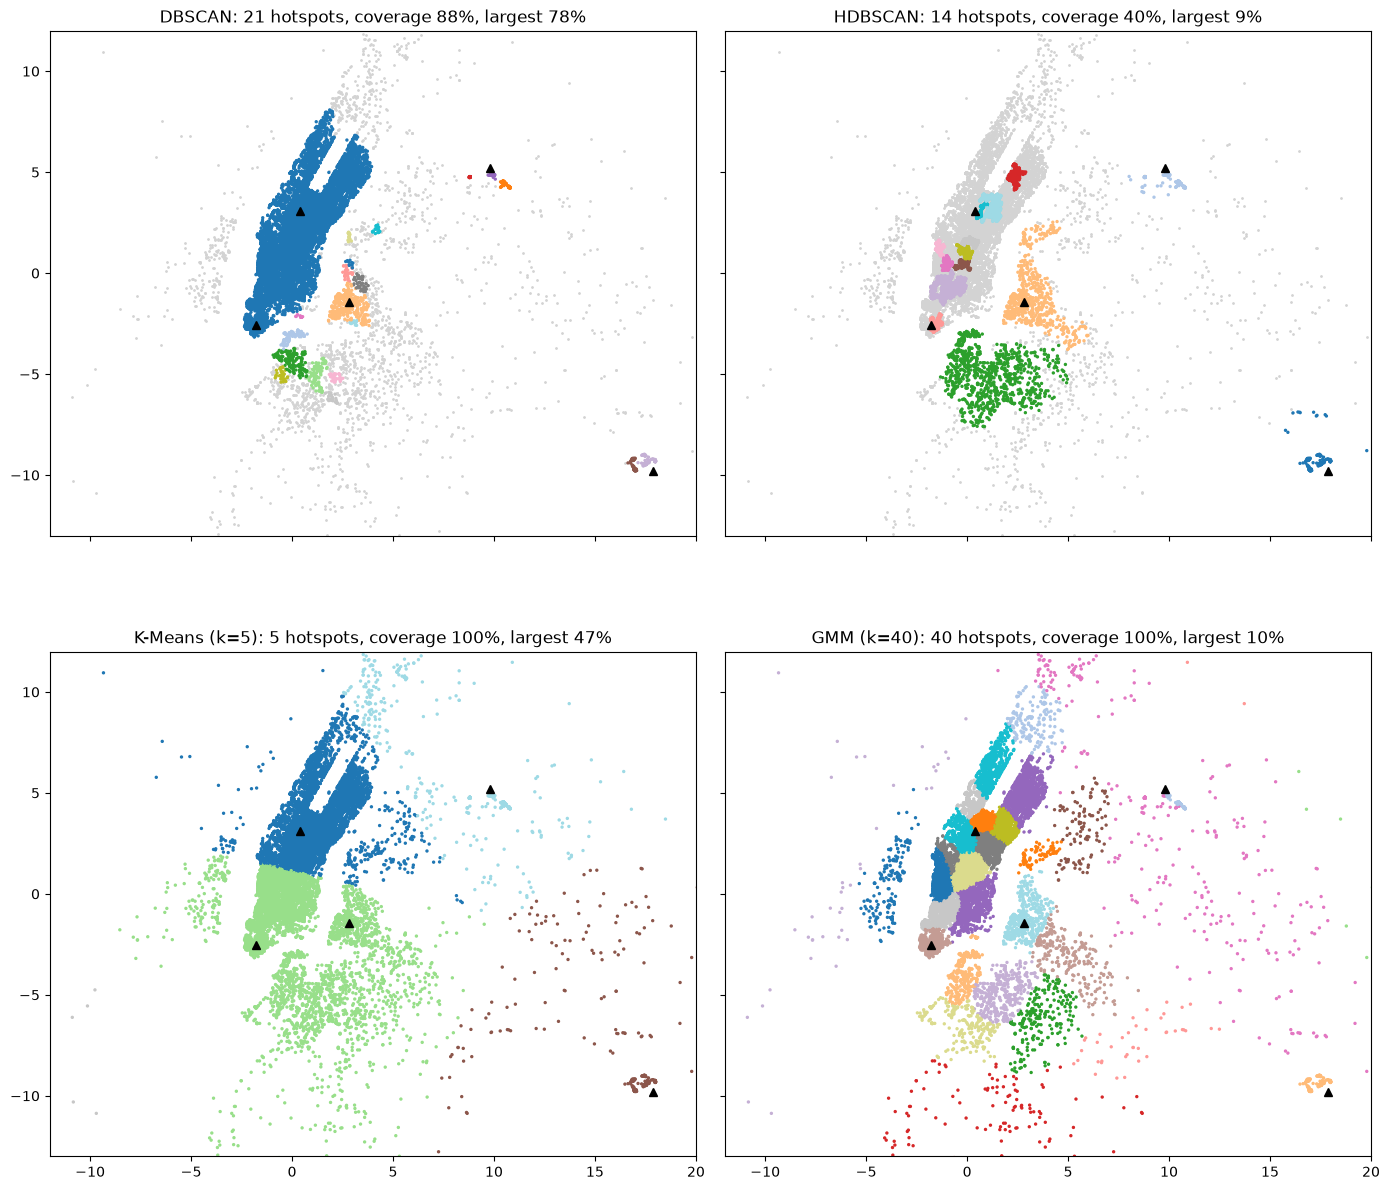

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(14, 13), sharex=True, sharey=True)
for ax, (name, lab) in zip(axes.ravel(), proj_labels.items()):
    ax.scatter(*proj_train[lab == -1].T, c="lightgrey", s=1)
    ax.scatter(*proj_train[lab >= 0].T, c=lab[lab >= 0] % 20, cmap="tab20", s=2)
    for mark in ["Times Square", "Wall Street", "JFK Airport", "LaGuardia Airport", "Williamsburg"]:
        ax.plot(*LANDMARK_XY[mark], "k^", ms=6)
    row = proj_table.loc[name]
    ax.set(title=f"{name}: {row['hotspots']} hotspots, coverage {row['coverage %']:.0f}%, largest {row['largest hotspot %']:.0f}%",
           xlim=(-12, 20), ylim=(-13, 12), aspect="equal")
plt.tight_layout()
plt.show()

### Step 6 — Choose with a rule written before looking at the ranking

A method qualifies if it **separates the airports** and **Midtown from Wall Street**, and its **largest hotspot holds under 25%** of pickups. Among qualifying methods, pick the highest persistence; break ties with the smaller median radius.

In [46]:
qualifies = proj_table[proj_table["airports separate"] & proj_table["Midtown ≠ Wall St"] & (proj_table["largest hotspot %"] < 25)]
pool = qualifies if len(qualifies) else proj_table
best_method = pool.sort_values(["persist %", "median radius km"], ascending=[False, True]).index[0]
print(f"qualifying methods: {list(qualifies.index) if len(qualifies) else 'none (ranking all methods)'} → chosen: {best_method}")

best_lab = proj_labels[best_method]
centres, sizes = hotspot_centres(proj_train, best_lab)
top = np.argsort(sizes)[::-1][:10]
rows = []
for rank, i in enumerate(top, start=1):
    lat, lon = to_latlon(centres[i])[0]
    nearest = min(LANDMARK_XY, key=lambda m: np.linalg.norm(LANDMARK_XY[m] - centres[i]))
    members = proj_train[best_lab == np.unique(best_lab[best_lab >= 0])[i]]
    rows.append({"rank": rank, "share of pickups %": 100 * sizes[i] / len(proj_train), "lat": round(lat, 4), "lon": round(lon, 4),
                 "radius km (90%)": np.quantile(np.linalg.norm(members - centres[i], axis=1), 0.9),
                 "nearest landmark": nearest, "km to landmark": np.linalg.norm(LANDMARK_XY[nearest] - centres[i])})
top_hotspots = pd.DataFrame(rows).set_index("rank")
print(top_hotspots.round(2).to_string())

qualifying methods: ['HDBSCAN', 'GMM (k=40)'] → chosen: HDBSCAN
      share of pickups %    lat    lon  radius km (90%)   nearest landmark  km to landmark
rank                                                                                      
1                   8.80  40.72 -74.00             0.82       West Village            1.11
2                   6.43  40.76 -73.97             0.65      Grand Central            0.79
3                   5.57  40.69 -73.98             2.42  Downtown Brooklyn            1.41
4                   3.90  40.72 -73.95             3.03       Williamsburg            0.50
5                   1.98  40.65 -73.78             0.61        JFK Airport            0.70
6                   1.94  40.77 -73.87             1.31  LaGuardia Airport            0.67
7                   1.82  40.74 -74.01             0.33       West Village            0.90
8                   1.75  40.74 -73.99             0.34       Union Square            0.38
9                   1.46  

### Step 7 — Conclusions (computed)

In [47]:
b = proj_table.loc[best_method]
giant = proj_table["largest hotspot %"].idxmax()
low_persist = proj_table["persist %"].idxmin()
print(f"1. {best_method} gives {b['hotspots']} hotspots covering {b['coverage %']:.0f}% of pickups, median radius {b['median radius km']:.2f} km, "
      f"largest hotspot {b['largest hotspot %']:.0f}%, and {b['persist %']:.0f}% of hotspots re-appear in the last week of April.")
print(f"2. {giant} has the biggest blob ({proj_table.loc[giant, 'largest hotspot %']:.0f}% of pickups in one hotspot)"
      + (" — one density threshold can't separate dense Manhattan neighbourhoods." if giant.startswith("DBSCAN") else "."))
print(f"3. K-Means and the GMM cover 100% of pickups by construction, so remote pickups are forced into oversized zones "
      f"(worst radius: K-Means {proj_table.filter(like='K-Means', axis=0)['worst radius km'].iloc[0]:.1f} km, "
      f"GMM {proj_table.filter(like='GMM', axis=0)['worst radius km'].iloc[0]:.1f} km).")
print(f"4. Lowest persistence: {low_persist} ({proj_table.loc[low_persist, 'persist %']:.0f}%); weekly hotspots from it would move around.")
print(f"5. The largest hotspot of {best_method} is near {top_hotspots.iloc[0]['nearest landmark']} "
      f"({top_hotspots.iloc[0]['km to landmark']:.1f} km away), holding {top_hotspots.iloc[0]['share of pickups %']:.1f}% of sampled pickups.")

1. HDBSCAN gives 14 hotspots covering 40% of pickups, median radius 0.49 km, largest hotspot 9%, and 93% of hotspots re-appear in the last week of April.
2. DBSCAN has the biggest blob (78% of pickups in one hotspot) — one density threshold can't separate dense Manhattan neighbourhoods.
3. K-Means and the GMM cover 100% of pickups by construction, so remote pickups are forced into oversized zones (worst radius: K-Means 13.0 km, GMM 45.3 km).
4. Lowest persistence: K-Means (k=5) (20%); weekly hotspots from it would move around.
5. The largest hotspot of HDBSCAN is near West Village (1.1 km away), holding 8.8% of sampled pickups.


**Stretch goals**
1. Split by **hour of day** (e.g. 7–10 am vs 5–8 pm) and compare the hotspots: do they move from residential areas to offices?
2. Use `metric="haversine"` everywhere instead of the km projection and confirm the results barely change.
3. Weight hotspots by **pickups per km²** and show a ranked list for dispatch.
4. Try `HDBSCAN(cluster_selection_epsilon=0.2)` (Malzer & Baum, 2019) to merge hotspots closer than 200 m.
5. Use the GMM log-density to flag unusual pickups in the test week and inspect where they are.

### 🗣️ How to talk about this in an interview
- "I framed hotspots as dense regions, not a partition, so noise had to be allowed. That points to DBSCAN/HDBSCAN, and I kept K-Means and a GMM as baselines."
- "All parameters came from the first three weeks: a business density rule for DBSCAN, 1% of the sample for HDBSCAN's `min_cluster_size`, silhouette for K-Means' k and BIC for the GMM. The last week was only used to test persistence."
- "I converted coordinates to kilometres so `eps` means the same distance in every direction, and I measured operational metrics: coverage, largest hotspot share, radius, airport separation, and week-over-week persistence using Hungarian matching of centres."
- "The selection rule was written before looking at the ranking; it traded coverage for compact, stable hotspots, and I reported the top hotspots with nearest landmarks so operations could sanity-check them."
- "Next I'd split by time of day and monitor the noise share and hotspot persistence as drift signals."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. How does DBSCAN work?**

<details><summary>Show answer</summary>

- **30-second answer:** Two parameters, `eps` and `min_samples`. A point with at least `min_samples` points within `eps` is a core point. Clusters grow by connecting core points that lie within `eps` of each other, and they absorb border points (non-core points near a core point). Everything else is noise. It finds the number of clusters itself and clusters can have any shape.
- **Go deeper:** Complexity is about $O(n \log n)$ with a spatial index in low dimensions and $O(n^2)$ in the worst case. In scikit-learn a point counts itself in `min_samples`. There's no `predict`; new points take the label of the nearest core point within `eps`. Memory can blow up with a large `eps` because neighbourhoods are stored.
- **❌ Common wrong answer:** "DBSCAN needs the number of clusters" or "noise points are assigned to the nearest cluster".

</details>

**Q2. How do you choose `eps` and `min_samples`?**

<details><summary>Show answer</summary>

- **30-second answer:** Pick `min_samples` first (≥ d+1, often 2·d, larger for noisy or big data). Then plot the sorted distance of each point to its `min_samples`-th neighbour and choose `eps` near the knee. Validate with the number of clusters, the noise share and the largest cluster, and with the business meaning of the density.
- **Go deeper:** Scale features first (one `eps` for every direction). For coordinates, use km or haversine. In our pickups the knee (well over 1 km) merged almost every pickup into one cluster, so a business rule (20 pickups within 250 m) or HDBSCAN was needed. If small changes in `eps` flip the result, densities probably vary.
- **❌ Common wrong answer:** "Grid-search `eps` to maximize silhouette" — silhouette favours convex clusters and ignores noise.

</details>

**Q3. When would you choose DBSCAN over K-Means, and vice versa?**

<details><summary>Show answer</summary>

- **30-second answer:** DBSCAN for arbitrary shapes, unknown k, and when outliers should stay unassigned, usually in low dimensions (coordinates). K-Means for compact blob-like clusters, a known k, when every point needs a label, when you need fast `predict`, or for large high-dimensional data.
- **Go deeper:** On moons and circles with injected noise, DBSCAN recovered the shapes and flagged the noise while K-Means cut them in half. On real pickups K-Means split Manhattan into straight-edged cells. On overlapping labelled tables (penguins, wine, digits), K-Means and GMMs beat density methods because there are no low-density gaps.
- **❌ Common wrong answer:** "DBSCAN is always better because it finds k automatically."

</details>

**Q4. Why does DBSCAN struggle with varying densities and high dimensions? What helps?**

<details><summary>Show answer</summary>

- **30-second answer:** One global `eps` defines one density threshold: small enough for dense areas means sparse clusters become noise, large enough for sparse areas means dense clusters merge. In high dimensions, distances concentrate (all pairs look similarly far), so neighbourhoods lose meaning. OPTICS and HDBSCAN handle varying density; dimensionality reduction (PCA/UMAP) helps in high dimensions.
- **Go deeper:** HDBSCAN uses mutual reachability $\max(\text{core}(a), \text{core}(b), d(a,b))$, builds an MST (DBSCAN for all `eps`), condenses with `min_cluster_size` and keeps the most stable clusters (`eom`) or leaves. OPTICS produces a reachability plot where valleys are clusters. Our table: strict DBSCAN → lots of noise, loose DBSCAN → one giant cluster, HDBSCAN leaf → many compact hotspots.
- **❌ Common wrong answer:** "Just tune `eps` better."

</details>

**Q5. Is DBSCAN deterministic?**

<details><summary>Show answer</summary>

- **30-second answer:** Almost. Core points and noise points are fully determined by the data and parameters. Border points reachable from two clusters go to whichever cluster reaches them first, so their labels can change with the data order.
- **Go deeper:** Our scratch implementation matched scikit-learn label-for-label because both scan in index order. Across 20 shuffled row orders, core points and noise never changed; only border points that touch two clusters can switch. The DBSCAN* variant (used inside HDBSCAN) avoids this by treating border points as noise.
- **❌ Common wrong answer:** "It uses random initialization like K-Means."

</details>

**Q6. What is a Gaussian mixture model and how does it differ from K-Means?**

<details><summary>Show answer</summary>

- **30-second answer:** A probabilistic model where data comes from $K$ Gaussians with weights $\pi_k$, means $\mu_k$ and covariances $\Sigma_k$. It gives soft assignments (posterior probabilities), models elliptical clusters with different sizes, and provides a likelihood. K-Means gives hard labels and implicitly assumes equal spherical clusters.
- **Go deeper:** K-Means is the limit of EM for a GMM with shared covariance $\sigma^2 I$, equal weights and $\sigma \to 0$. GMMs allow BIC model selection, sampling and density-based anomaly scores, but cost $O(nkd^2)$ per iteration with full covariance and can overfit in high dimensions.
- **❌ Common wrong answer:** "A GMM is K-Means with probabilities added at the end."

</details>

**Q7. Explain the EM algorithm. Why does the likelihood increase?**

<details><summary>Show answer</summary>

- **30-second answer:** EM maximizes a likelihood with hidden variables (which component generated each point). E-step: compute responsibilities with Bayes' rule under the current parameters. M-step: re-estimate weights, means and covariances as responsibility-weighted averages. Repeat until the log-likelihood stops improving.
- **Go deeper:** Jensen's inequality gives a lower bound on the log-likelihood for any distribution over the hidden variables. The E-step makes the bound tight at the current parameters; the M-step maximizes the bound, so the likelihood can't decrease. It converges to a local maximum or saddle point. EM also fits HMMs (Baum–Welch), handles missing data, and underlies many latent-variable models.
- **❌ Common wrong answer:** "EM is gradient descent on the likelihood" or "EM finds the global optimum".

</details>

**Q8. Which covariance type would you use, and how do you choose the number of components?**

<details><summary>Show answer</summary>

- **30-second answer:** `full` for flexible, differently oriented ellipses when data is plentiful; `tied` if clusters share a shape; `diag` for many features or less data; `spherical` for the simplest K-Means-like model. Choose k and the type together by the lowest BIC (or AIC), then sanity-check stability and meaning.
- **Go deeper:** Parameters: means $kd$, weights $k-1$, covariances full $kd(d+1)/2$, tied $d(d+1)/2$, diag $kd$, spherical $k$. BIC $= -2\log L + p\ln n$ penalizes more than AIC $= -2\log L + 2p$. On the penguins BIC chose a model that differs from the species split: it optimizes density fit, not your labels. `BayesianGaussianMixture` can prune components automatically.
- **❌ Common wrong answer:** "Choose the k with the highest likelihood" — that always picks the biggest model.

</details>

**Q9. What can go wrong when fitting a GMM, and how do you fix it?**

<details><summary>Show answer</summary>

- **30-second answer:** Local optima (fix: `n_init` > 1, K-Means initialization), singular or collapsing covariances when a component sits on one point or a feature is constant (fix: `reg_covar`, `diag` covariance, dimensionality reduction, fewer components), and poor fits when clusters aren't Gaussian (fix: more components, a transformation, or a density-based method).
- **Go deeper:** We saw the log-likelihood range of `n_init=1` runs narrow with `n_init=10`, and a full-covariance fit on digit pixels with `reg_covar=0` fail while `diag` worked. Scale features, and check `converged_` and `n_iter_`.
- **❌ Common wrong answer:** "Increase `max_iter` until it converges" — that doesn't help with singular covariances or bad local optima.

</details>

**Q10. How can clustering methods be used for anomaly detection?**

<details><summary>Show answer</summary>

- **30-second answer:** DBSCAN/HDBSCAN: noise points are anomalies. GMM: `score_samples` gives log-density; flag points below a threshold (e.g. the 1st percentile of training scores). K-Means: large distance to the nearest centroid.
- **Go deeper:** Pick thresholds on training/validation data only, and measure the flag rate on new data (we got close to the expected 1% on the next week's pickups). Density estimates suffer in high dimensions. Dedicated methods (Isolation Forest, LOF) are compared in the anomaly detection notebook.
- **❌ Common wrong answer:** "Tune the threshold on the test set until the anomaly rate looks right."

</details>

### 💻 Coding

**Q11. Write a numerically stable, vectorized E-step for a GMM.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```python
  log_p = np.column_stack([np.log(w[k]) + log_gaussian(X, mu[k], cov[k]) for k in range(K)])   # (n, K)
  log_norm = np.logaddexp.reduce(log_p, axis=1)        # log p(x_i)
  resp = np.exp(log_p - log_norm[:, None])             # rows sum to 1
  mean_loglik = log_norm.mean()
  ```
- **Go deeper:** Compute `log_gaussian` with a Cholesky factor: $\log|\Sigma| = 2\sum \log L_{jj}$, Mahalanobis term via a triangular solve, never an explicit inverse. Working in log space avoids underflow when densities are tiny. Our scratch EM built this way matched scikit-learn's log-likelihood to machine precision.
- **❌ Common wrong answer:** Multiplying raw densities and normalizing, which underflows to 0/0 = NaN in high dimensions.

</details>

**Q12. Sketch DBSCAN's clustering loop.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```python
  labels = [-1] * n; c = 0
  for i in range(n):
      if labels[i] != -1 or not core[i]: continue
      labels[i] = c; stack = [i]
      while stack:
          p = stack.pop()
          for q in neighbours[p]:
              if labels[q] == -1:
                  labels[q] = c
                  if core[q]: stack.append(q)
      c += 1
  ```
- **Go deeper:** Neighbourhoods come from a KD-/ball tree (`radius_neighbors`) instead of the $O(n^2)$ distance matrix. Only core points are expanded, which is why border points never pass density on. Mention the border-order ambiguity.
- **❌ Common wrong answer:** Expanding from border points too, which chains clusters through sparse regions.

</details>

### 🐛 Debugging Scenarios

**Q13. DBSCAN returns one huge cluster, or labels almost everything as noise. What do you check?**

<details><summary>Show answer</summary>

- **30-second answer:** `eps` relative to the data scale: one giant cluster means `eps` is too large or `min_samples` too small; all noise means the opposite. Check feature scaling (and degrees vs km for coordinates), redraw the k-distance plot, and inspect the noise share and largest cluster. If no `eps` gives both, densities vary: use HDBSCAN.
- **Go deeper:** Also check duplicated points (many identical coordinates inflate density), high dimensionality (reduce first), and the metric. Our grid showed noise going from about 30% to a few percent and the largest cluster growing past 75% as `eps` grew.
- **❌ Common wrong answer:** "DBSCAN doesn't work on this data" without checking scale and `eps`.

</details>

**Q14. `GaussianMixture.fit` fails with "ill-defined empirical covariance". What's happening and how do you fix it?**

<details><summary>Show answer</summary>

- **30-second answer:** A covariance matrix became singular: a component collapsed onto very few points, features are constant or perfectly correlated, or there are too many dimensions per component. Increase `reg_covar`, use `diag`/`tied`/`spherical` covariance, reduce components or dimensions (PCA), remove constant features, and scale the data.
- **Go deeper:** We reproduced it on digit pixels with `reg_covar=0` and full covariance; `diag` with the default `reg_covar=1e-6` fitted fine. Duplicated rows can also cause collapse. `BayesianGaussianMixture` adds priors that regularize covariances.
- **❌ Common wrong answer:** "Set `max_iter` higher" or "use float32".

</details>

### 🏗️ Design

**Q15. Design a system that finds pickup hotspots for a ride-hailing company and keeps them up to date.**

<details><summary>Show answer</summary>

- **30-second answer:** Project coordinates to km (or use haversine), segment by time window (hour of day, weekday/weekend), run HDBSCAN (or DBSCAN with a business density rule) per window on a recent rolling period, and publish hotspot centres, radii and pickup shares. Assign live requests to hotspots with the nearest-core-point rule. Refresh daily or weekly, match new hotspots to old ones (Hungarian matching on centres) to keep stable IDs, and monitor the noise share and hotspot persistence.
- **Go deeper:** Scale with spatial partitioning (geohash/H3 cells) and approximate neighbour search; evaluate by operational outcomes (pickup wait time, driver idle time) in an A/B test, not just cluster metrics; handle events (concerts, weather) with shorter windows; keep a fallback for areas with little data. A GMM density on top can score unusual requests.
- **❌ Common wrong answer:** "Run K-Means with k=50 on all historical pickups once and hard-code the centroids."

</details>

## 🧪 Quick Quiz

Predict the answer, then reveal. (Every answer was verified by running it with the versions in the header.)

**1.** `DBSCAN(eps=0.5, min_samples=2).fit_predict([[0], [0.4], [5]])`
<details><summary>Answer</summary>

`array([ 0,  0, -1])` — 0 and 0.4 are within 0.5 of each other, so each has 2 points (itself included) and both are core; 5 is noise.
</details>

**2.** `hasattr(DBSCAN(), "predict"), hasattr(GaussianMixture(), "predict_proba")`
<details><summary>Answer</summary>

`(False, True)` — DBSCAN only has `fit_predict`; a GMM predicts hard labels and probabilities for new points.
</details>

**3.** How many free parameters does `GaussianMixture(n_components=3, covariance_type="diag")` have on 4 features?
<details><summary>Answer</summary>

`26` — means 3·4 = 12, variances 3·4 = 12, weights 3 − 1 = 2.
</details>

**4.** `DBSCAN(eps=1, min_samples=5).fit_predict([[0, 0], [0.1, 0], [0, 0.1], [0.1, 0.1]])`
<details><summary>Answer</summary>

`array([-1, -1, -1, -1])` — all four points are close, but no point has 5 neighbours (there are only 4 points), so there are no core points and everything is noise.
</details>

**5.** What do the rows of `GaussianMixture(2).fit(X).predict_proba(X)` sum to?
<details><summary>Answer</summary>

`1.0` for every row — they are the posterior probabilities (responsibilities) over the components.
</details>

## 📚 Resources

### 📖 Official Docs
- [scikit-learn — 2.3. Clustering](https://scikit-learn.org/stable/modules/clustering.html) — the DBSCAN, OPTICS and HDBSCAN sections with their parameters and complexity notes
- [scikit-learn — 2.1. Gaussian mixture models](https://scikit-learn.org/stable/modules/mixture.html) — EM, covariance types, BIC and the variational Bayesian GMM
- [scikit-learn — HDBSCAN](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.HDBSCAN.html) — API reference for the version used here
- [scikit-learn example — Demo of OPTICS clustering algorithm](https://scikit-learn.org/stable/auto_examples/cluster/plot_optics.html) — reachability plots and extraction
- [scikit-learn example — Gaussian Mixture Model Selection](https://scikit-learn.org/stable/auto_examples/mixture/plot_gmm_selection.html) — BIC over k and covariance types
- [scikit-learn example — GMM covariances](https://scikit-learn.org/stable/auto_examples/mixture/plot_gmm_covariances.html) — what each covariance type looks like
- [hdbscan documentation — How HDBSCAN Works](https://hdbscan.readthedocs.io/en/latest/how_hdbscan_works.html) — a picture-by-picture explanation of mutual reachability, the MST and the condensed tree
- [GitHub — fivethirtyeight/uber-tlc-foil-response](https://github.com/fivethirtyeight/uber-tlc-foil-response) — the pickup data and its origin

### 🎥 Videos
- [StatQuest (Josh Starmer) — Clustering with DBSCAN, Clearly Explained!!!](https://www.youtube.com/watch?v=RDZUdRSDOok) (~9 min) — core, border and noise points drawn step by step; watch before Section 1
- [Luis Serrano — Gaussian Mixture Models](https://www.youtube.com/watch?v=q71Niz856KE) (~17 min) — a friendly visual introduction to soft clustering and the EM loop; watch before Section 6
- [Alexander Ihler — Clustering (4): Gaussian Mixture Models and EM](https://www.youtube.com/watch?v=qMTuMa86NzU) (~17 min) — the E and M step formulas from a university course; watch before Section 7

### 📄 Papers
- [Ester, Kriegel, Sander & Xu (1996) — A Density-Based Algorithm for Discovering Clusters in Large Spatial Databases with Noise](https://cdn.aaai.org/KDD/1996/KDD96-037.pdf) — the original DBSCAN paper
- [Ankerst, Breunig, Kriegel & Sander (1999) — OPTICS: Ordering Points To Identify the Clustering Structure](https://dl.acm.org/doi/10.1145/304181.304187) — reachability plots
- [Campello, Moulavi & Sander (2013) — Density-Based Clustering Based on Hierarchical Density Estimates](https://link.springer.com/chapter/10.1007/978-3-642-37456-2_14) — HDBSCAN
- [McInnes & Healy (2017) — Accelerated Hierarchical Density Clustering](https://arxiv.org/abs/1705.07321) — the fast HDBSCAN implementation behind the `hdbscan` package
- [Malzer & Baum (2019) — A Hybrid Approach To Hierarchical Density-based Cluster Selection](https://arxiv.org/abs/1911.02282) — `cluster_selection_epsilon`
- [Schubert, Sander, Ester, Kriegel & Xu (2017) — DBSCAN Revisited, Revisited: Why and How You Should (Still) Use DBSCAN](https://dl.acm.org/doi/10.1145/3068335) — complexity, parameter choice and common misconceptions

### 📘 Books & Courses
- [Bishop — Pattern Recognition and Machine Learning (free PDF)](https://www.microsoft.com/en-us/research/uploads/prod/2006/01/Bishop-Pattern-Recognition-and-Machine-Learning-2006.pdf) — Chapter 9: mixture models and EM, including the K-Means connection
- [Stanford CS229 lecture notes (PDF)](https://cs229.stanford.edu/main_notes.pdf) — the EM algorithm and mixtures of Gaussians derived with Jensen's inequality
- [Python Data Science Handbook — In Depth: Gaussian Mixture Models](https://jakevdp.github.io/PythonDataScienceHandbook/05.12-gaussian-mixtures.html) — Jake VanderPlas, GMMs for clustering and density estimation

### 🏋️ Practice
- [Kaggle Learn — Geospatial Analysis Tutorials](https://www.kaggle.com/learn/geospatial-analysis) — working with coordinates, projections and proximity in the browser
- [scikit-learn example — Comparing different clustering algorithms on toy datasets](https://scikit-learn.org/stable/auto_examples/cluster/plot_cluster_comparison.html) — change the parameters and predict each algorithm's behaviour before running it

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / formula |
|---|---|---|
| DBSCAN | clusters = density-connected core points + borders; noise = −1 | `DBSCAN(eps, min_samples)`, `core_sample_indices_`, `labels_` |
| Core / border / noise | ≥ `min_samples` within `eps` / near a core / neither | $N_\varepsilon(p) = \{q : d(p,q) \le \varepsilon\}$ (includes p) |
| k-distance plot | choose `eps` at the knee | `NearestNeighbors(n_neighbors=min_samples).kneighbors(X)[0][:, -1]`, sorted |
| Coordinates | make `eps` mean kilometres | project to km, or `metric="haversine"` on radians with `eps = km / 6371` |
| OPTICS | reachability ordering; valleys = clusters | `OPTICS(min_samples, xi)`, `reachability_[ordering_]`, `cluster_optics_dbscan` |
| HDBSCAN | DBSCAN over all `eps`, keeps stable clusters | `HDBSCAN(min_cluster_size, min_samples, cluster_selection_method, copy=True)`, `probabilities_` |
| Mutual reachability | pushes sparse points apart | $\max(\text{core}_k(a), \text{core}_k(b), d(a,b))$ |
| Noise handling | report, keep, flag, or assign new points | nearest core point within `eps`; monitor noise share |
| GMM | weighted sum of Gaussians, soft labels | $p(x) = \sum_k \pi_k \mathcal{N}(x \mid \mu_k, \Sigma_k)$, `GaussianMixture(...).predict_proba` |
| E-step | responsibilities by Bayes' rule | $\gamma_{ik} = \pi_k \mathcal{N}_{ik} / \sum_j \pi_j \mathcal{N}_{ij}$ (log space: `logaddexp`) |
| M-step | weighted refit | $\pi_k = N_k/n$, $\mu_k = \sum_i \gamma_{ik} x_i / N_k$, $\Sigma_k = \sum_i \gamma_{ik}(x_i-\mu_k)(x_i-\mu_k)^\top / N_k$ |
| Covariance types | flexibility vs parameters | `full` $kd(d+1)/2$, `tied` $d(d+1)/2$, `diag` $kd$, `spherical` $k$ |
| Model selection | penalized likelihood | BIC $= -2\log L + p\ln n$, AIC $= -2\log L + 2p$; `gmm.bic(X)`, `gmm.aic(X)` |
| Anomaly score | low density = unusual | `score_samples(X)` < training percentile |
| Stability tricks | avoid bad optima / singularities | `n_init`, `reg_covar`, `covariance_type="diag"`, PCA first |

## ➡️ What's Next

**[14 · Dimensionality Reduction — PCA, t-SNE and UMAP](14_Dimensionality_Reduction_PCA_tSNE_UMAP.ipynb)** — density-based clustering and Gaussian mixtures break down in high dimensions, as the digits showed. Next you'll learn to compress and visualize high-dimensional data with PCA, t-SNE and UMAP, which is often the step right before clustering.